In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("/Bank Data.csv")
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,4,12.27,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,5,11.27,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [4]:
df.isnull().sum()

ID                             0
Customer_ID                    0
Month                          0
Name                        5015
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5704
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4470
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Payment_Behaviour              0
Monthly_Balance              562
dtype: int64

In [5]:
df.drop(columns=['ID','Customer_ID','SSN','Name','Type_of_Loan','Payment_Behaviour'],inplace=True)
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,September,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,186.26670208571772
1,October,24,Scientist,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,361.44400385378196
2,November,24,Scientist,19114.12,1824.843333,3,4,3,4,-1,4,12.27,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,264.67544623342997
3,December,24_,Scientist,19114.12,NaN,3,4,3,4,4,5,11.27,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,343.82687322383634
4,September,28,_______,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,485.2984336755923


In [6]:
df.shape

(50000, 21)

In [7]:
df.Credit_Mix.value_counts().head(10)

Standard    18379
Good        12260
_            9805
Bad          9556
Name: Credit_Mix, dtype: int64

In [8]:
# Assuming df is your DataFrame
df['Credit_Mix'].replace('_', 'neutral', inplace=True)
df['Credit_Mix'].fillna('neutral', inplace=True)


In [9]:
df.Credit_Mix.value_counts().head(10)

Standard    18379
Good        12260
neutral      9805
Bad          9556
Name: Credit_Mix, dtype: int64

In [10]:
df.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4470
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Monthly_Balance              562
dtype: int64

In [11]:
df.Delay_from_due_date.value_counts().sample(40)

 55     296
 39     250
 25    1289
 11    1573
 2      669
 9     1656
 20    1300
-3       59
 37     267
 15    1759
 62     279
 31     397
 53     291
 41     307
 48     363
 17    1183
 50     270
 38     306
 56     283
 18    1335
 34     320
-5       18
 14    1636
 52     302
 10    1645
 58     282
 67       7
 12    1625
 59     250
 29    1223
 13    1761
 57     269
 3      848
 66      12
 1      668
 45     269
 4      825
 22    1135
-2       71
 54     308
Name: Delay_from_due_date, dtype: int64

**Convert String to Float of Credit_History_Age column also fill the null value with it's mean**

*After doing a lot of analyis I have found all 'Credit_History_Age	' null cause I have to convert all of str to float/int value. For this operation 'Credit_History_Age' columns became null. But I need this column. So that I'm do it preprocessing. I have taken only integer value from this columns that would be standard*

In [12]:
def extract_age(row):
    if isinstance(row, str):
        years, months = 0, 0
        if 'Years' in row:
            years = int(row.split(' Years')[0])
        if 'Months' in row:
            months = int(row.split('and ')[1].split(' Months')[0])
        return years + months / 12
    else:
        return np.nan

df['Credit_History_Age'] = df['Credit_History_Age'].apply(extract_age)

# Fill missing values with the mean
mean_age = df['Credit_History_Age'].mean()
df['Credit_History_Age'].fillna(mean_age, inplace=True)

In [13]:
df.head(5)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,September,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,Good,809.98,35.030402,22.750000,No,49.574949,236.64268203272135,186.26670208571772
1,October,24,Scientist,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,Good,809.98,33.053114,22.833333,No,49.574949,21.465380264657146,361.44400385378196
2,November,24,Scientist,19114.12,1824.843333,3,4,3,4,-1,4,12.27,4.0,Good,809.98,33.811894,18.937598,No,49.574949,148.23393788500925,264.67544623342997
3,December,24_,Scientist,19114.12,NaN,3,4,3,4,4,5,11.27,4.0,Good,809.98,32.430559,23.000000,No,49.574949,39.08251089460281,343.82687322383634
4,September,28,_______,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,Good,605.03,25.926822,27.250000,No,18.816215,39.684018417945296,485.2984336755923


In [14]:
df.Payment_of_Min_Amount.value_counts()

Yes    26158
No     17849
NM      5993
Name: Payment_of_Min_Amount, dtype: int64

In [15]:
df.Occupation.value_counts()

_______          3438
Lawyer           3324
Engineer         3212
Architect        3195
Mechanic         3168
Developer        3146
Accountant       3133
Media_Manager    3130
Scientist        3104
Teacher          3103
Entrepreneur     3103
Journalist       3037
Doctor           3027
Manager          3000
Musician         2947
Writer           2933
Name: Occupation, dtype: int64

In [16]:
import numpy as np

# Replace "_______" with NaN
df['Occupation'].replace("_______", np.nan, inplace=True)

# Get the list of occupations
occupations_list = ["Lawyer", "Engineer", "Architect", "Mechanic", "Developer", "Accountant",
                    "Media_Manager", "Scientist", "Teacher", "Entrepreneur", "Journalist",
                    "Doctor", "Manager", "Musician", "Writer"]

# Replace NaN values with random values from the list
nan_mask = df['Occupation'].isnull()
df.loc[nan_mask, 'Occupation'] = np.random.choice(occupations_list, size=nan_mask.sum())


In [17]:
df.Occupation.value_counts()

Lawyer           3556
Architect        3436
Mechanic         3423
Engineer         3411
Accountant       3371
Developer        3365
Media_Manager    3356
Scientist        3352
Entrepreneur     3334
Teacher          3322
Journalist       3250
Doctor           3244
Manager          3234
Musician         3188
Writer           3158
Name: Occupation, dtype: int64

In [18]:
df.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Monthly_Balance              562
dtype: int64

In [19]:
df.shape


(50000, 21)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       50000 non-null  object 
 2   Occupation                50000 non-null  object 
 3   Annual_Income             50000 non-null  object 
 4   Monthly_Inhand_Salary     42502 non-null  float64
 5   Num_Bank_Accounts         50000 non-null  int64  
 6   Num_Credit_Card           50000 non-null  int64  
 7   Interest_Rate             50000 non-null  int64  
 8   Num_of_Loan               50000 non-null  object 
 9   Delay_from_due_date       50000 non-null  int64  
 10  Num_of_Delayed_Payment    46502 non-null  object 
 11  Changed_Credit_Limit      50000 non-null  object 
 12  Num_Credit_Inquiries      48965 non-null  float64
 13  Credit_Mix                50000 non-null  object 
 14  Outsta

**Those columns shoud be numerical values but it has as string now I'm converting them**

In [21]:
# Assuming our DataFrame is named 'df'
columns_to_convert = ['Age', 'Annual_Income','Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
                       'Changed_Credit_Limit','Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

# Convert selected columns to numeric types
df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')

# Check the data types after conversion
print(df.dtypes)


Month                        object
Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                 float64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
dtype: object


In [22]:
df.isnull().sum()

Month                          0
Age                         2477
Occupation                     0
Annual_Income               3520
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                 2436
Delay_from_due_date            0
Num_of_Delayed_Payment      4925
Changed_Credit_Limit        1059
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

**Work wiht Monthly_Inhand_Salary columns and fill all missing rows by it's mean**

In [23]:
df['Monthly_Inhand_Salary'].value_counts().tail(45)

1792.315000     1
1916.121667     1
1966.027083     1
6617.557500     1
3158.531385     1
2714.053557     1
9477.328612     1
7405.809676     1
3303.945000     1
7005.635000     1
873.865417      1
8343.470000     1
6765.796667     1
6204.196083     1
1158.442083     1
8188.211724     1
3750.272500     1
2836.380833     1
8717.732500     1
7823.998705     1
12318.281290    1
2438.323333     1
1801.474167     1
1497.882500     1
926.473333      1
3312.502174     1
14241.603333    1
8437.365531     1
887.077917      1
1488.550000     1
5708.490000     1
4473.288333     1
3792.167500     1
1183.864167     1
11643.130049    1
6107.183333     1
683.253333      1
1039.349084     1
689.187083      1
1652.952966     1
12386.966240    1
5993.870000     1
6763.330000     1
7729.695181     1
2312.785000     1
Name: Monthly_Inhand_Salary, dtype: int64

In [24]:

average_monthly_salary = df['Monthly_Inhand_Salary'].mean()
df['Monthly_Inhand_Salary'].fillna(value=average_monthly_salary, inplace=True)

df.isnull().sum()


Month                          0
Age                         2477
Occupation                     0
Annual_Income               3520
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                 2436
Delay_from_due_date            0
Num_of_Delayed_Payment      4925
Changed_Credit_Limit        1059
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

**Age never could be negative so that I remove all negative valuse and fill it's by it's mean**

In [25]:
df['Age'].value_counts().head(45)

 39.0      1493
 32.0      1440
 44.0      1428
 22.0      1422
 35.0      1414
 37.0      1397
 27.0      1382
 20.0      1374
 29.0      1368
 26.0      1348
 28.0      1344
 30.0      1341
 41.0      1338
 25.0      1325
 36.0      1318
 24.0      1318
 33.0      1280
 42.0      1277
 19.0      1277
 38.0      1266
 31.0      1265
 21.0      1260
 34.0      1236
 23.0      1213
 45.0      1208
 40.0      1196
 43.0      1193
 46.0      1127
 18.0       796
 15.0       744
 16.0       731
 17.0       720
 53.0       657
 50.0       653
 55.0       647
 49.0       644
 47.0       624
 54.0       623
 51.0       610
 52.0       593
 48.0       593
 56.0       498
-500.0      464
 14.0       181
 3287.0       2
Name: Age, dtype: int64

In [26]:
df['Age'] = df['Age'].apply(lambda x: x if (x >= 0 and x <= 100) else np.nan)
mean_age = df['Age'].mean()
df['Age'].fillna(mean_age, inplace=True)

df.isnull().sum()


Month                          0
Age                            0
Occupation                     0
Annual_Income               3520
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                 2436
Delay_from_due_date            0
Num_of_Delayed_Payment      4925
Changed_Credit_Limit        1059
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

**Working wiht Annual_Income Column**

In [27]:
df['Annual_Income'].value_counts().head(45)

109945.320    8
17816.750     8
9141.630      8
36585.120     8
72524.200     8
95596.350     8
22434.160     8
33029.660     7
20867.670     7
40341.160     7
17273.830     6
32543.380     5
43790.400     4
28431.060     4
43268.790     4
108638.760    4
32198.230     4
138920.840    4
56784.540     4
7577.175      4
50807.440     4
13864.835     4
145932.040    4
19183.530     4
68948.320     4
24778.800     4
66189.240     4
20560.130     4
14226.810     4
83552.120     4
37353.580     4
151437.080    4
13000.735     4
14888.915     4
100465.140    4
16697.830     4
20090.020     4
94256.480     4
7295.715      4
18500.540     4
35317.810     4
25703.340     4
70973.320     4
121233.510    4
71518.920     4
Name: Annual_Income, dtype: int64

In [28]:
# Calculate the mean of the 'Annual_Income' column
mean_annual_income = df['Annual_Income'].mean()

# Fill missing values with the mean
df['Annual_Income'].fillna(mean_annual_income, inplace=True)
df.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                 2436
Delay_from_due_date            0
Num_of_Delayed_Payment      4925
Changed_Credit_Limit        1059
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

In [29]:

average_monthly_salary = df['Monthly_Inhand_Salary'].mean()
df['Monthly_Inhand_Salary'].fillna(value=average_monthly_salary, inplace=True)

df.isnull().sum()


Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                 2436
Delay_from_due_date            0
Num_of_Delayed_Payment      4925
Changed_Credit_Limit        1059
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

****Working wiht Number_of_Delayed_payment columns and fill it's missing rows with it's random vlaues those values are has most frequently in this columns****

In [30]:
df['Num_of_Delayed_Payment'].value_counts().head(50)

 19.0      2622
 15.0      2594
 18.0      2570
 16.0      2548
 17.0      2545
 10.0      2517
 12.0      2483
 11.0      2440
 20.0      2422
 9.0       2365
 8.0       2352
 14.0      2007
 13.0      2000
 21.0      1315
 7.0       1140
 22.0      1116
 6.0       1076
 5.0       1036
 23.0      1011
 3.0        939
 4.0        887
 2.0        872
 24.0       836
 1.0        814
 25.0       813
 0.0        784
 26.0       147
-1.0        123
 27.0       104
-2.0        103
 28.0        64
-3.0         49
 2606.0       3
 538.0        2
 265.0        2
 549.0        2
 688.0        2
 2583.0       2
 3064.0       2
 1377.0       2
 2649.0       2
 762.0        2
 2608.0       2
 861.0        2
 3425.0       2
 2595.0       2
 3666.0       1
 1718.0       1
 1344.0       1
 4206.0       1
Name: Num_of_Delayed_Payment, dtype: int64

In [31]:

# Create a list of the top most common values
top_values = [19, 15, 18, 16, 17, 10, 11, 12, 20, 9, 8, 14, 13, 21, 7, 22, 6, 5, 23, 3, 4, 2, 24, 1, 25, 0]

# Replace negative numbers with NaN
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].apply(lambda x: x if x >= 0 else np.nan)

# Replace missing values with the top values
missing_indices = df['Num_of_Delayed_Payment'].isnull()
df.loc[missing_indices, 'Num_of_Delayed_Payment'] = np.random.choice(top_values, size=missing_indices.sum())


**Working wiht Num_of_Loan columns and fill it's missing rows with it's random vlaues those values are has most frequently in this columns**

In [32]:
df.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                 2436
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit        1059
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

In [33]:
df.Num_of_Loan.value_counts().head(25)

 2.0       7173
 3.0       7114
 4.0       6982
 0.0       5163
 1.0       5029
 6.0       3707
 7.0       3483
 5.0       3437
-100.0     1974
 9.0       1746
 8.0       1506
 1237.0       2
 463.0        2
 452.0        2
 505.0        2
 286.0        2
 1475.0       2
 1024.0       2
 1445.0       2
 106.0        2
 198.0        2
 385.0        2
 602.0        2
 140.0        2
 263.0        2
Name: Num_of_Loan, dtype: int64

In [34]:

# Replace negative numbers with NaN
df['Num_of_Loan'] = df['Num_of_Loan'].apply(lambda x: x if x >= 0 else np.nan)

# Create a list of the top most common values
top_values = [2.0, 3.0, 4.0, 0.0, 1.0, 6.0, 7.0, 5.0, 9.0, 8.0]

# Replace missing values with the top values
missing_indices = df['Num_of_Loan'].isnull()
df.loc[missing_indices, 'Num_of_Loan'] = np.random.choice(top_values, size=missing_indices.sum())

df.isnull().sum()


Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit        1059
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

**working with Changed_Credite_Limint column**

In [35]:
negative_changed_limit = df[df['Changed_Credit_Limit'] < 0]
print(negative_changed_limit['Changed_Credit_Limit'].value_counts().head(10))


-4.08    5
-0.79    5
-2.50    5
-2.03    5
-1.41    5
-0.60    4
-1.46    4
-3.22    4
-0.67    4
-0.99    4
Name: Changed_Credit_Limit, dtype: int64


In a financial context, a negative value for "Changed_Credit_Limit" might represent a reduction or decrease in the credit limit. In some cases, financial institutions or credit card companies may decrease a person's credit limit based on various factors such as changes in creditworthiness, missed payments, or other risk-related considerations.

In [36]:
mean_credit_limit = df['Changed_Credit_Limit'].mean()

# Fill missing values with the mean
df['Changed_Credit_Limit'].fillna(mean_credit_limit, inplace=True)
df.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

**Working with Num_Credit_Inquiries column**

In [37]:
df['Num_Credit_Inquiries'].value_counts().head(50)

5.0       4709
4.0       4402
6.0       4375
7.0       4295
8.0       3922
9.0       3523
3.0       3466
11.0      2996
10.0      2982
12.0      2585
2.0       2454
13.0      2065
1.0       1747
14.0      1394
0.0       1102
15.0      1063
16.0       651
17.0       388
2326.0       3
2338.0       3
1431.0       3
1823.0       3
2019.0       3
1856.0       3
1785.0       3
2179.0       2
1984.0       2
1902.0       2
824.0        2
1990.0       2
2013.0       2
1808.0       2
951.0        2
593.0        2
881.0        2
396.0        2
1879.0       2
695.0        2
1551.0       2
323.0        2
151.0        2
2034.0       2
140.0        2
1138.0       2
2328.0       2
801.0        2
1228.0       2
1694.0       2
2292.0       2
1416.0       2
Name: Num_Credit_Inquiries, dtype: int64

In [38]:
# Set the number of rows to fill
num_rows_to_fill = 1035

# Generate random values between 1 and 20
random_values = np.random.randint(1, 21, size=num_rows_to_fill)

# Find the indices of missing values in 'Num_Credit_Inquiries'
missing_indices = df['Num_Credit_Inquiries'].isnull()

# Replace missing values with random values
df.loc[missing_indices, 'Num_Credit_Inquiries'] = random_values

In [39]:
df.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt             491
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4446
Monthly_Balance              568
dtype: int64

**Working wiht Amount_invested_monthly column**

In [40]:
df['Amount_invested_monthly'].value_counts().tail(50)

793.597186    1
109.524179    1
82.571977     1
102.658023    1
79.782635     1
285.343947    1
57.534533     1
748.625498    1
49.893509     1
63.272686     1
221.333884    1
36.952274     1
18.184504     1
13.825182     1
17.913243     1
42.322310     1
158.080629    1
11.908091     1
188.822031    1
445.518708    1
257.173563    1
352.895283    1
188.628242    1
262.440115    1
168.210066    1
77.923151     1
92.694694     1
49.231406     1
40.952555     1
74.746469     1
735.175586    1
130.785144    1
390.765481    1
192.343397    1
409.051633    1
610.385627    1
687.238659    1
793.371509    1
189.034767    1
54.865397     1
41.622649     1
247.478334    1
183.951614    1
147.419348    1
592.143969    1
197.217131    1
366.231484    1
34.899406     1
256.908305    1
220.457878    1
Name: Amount_invested_monthly, dtype: int64

In [41]:
# Convert 'Amount_invested_monthly' to numeric, handling errors with 'coerce'
#df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')

# Calculate the mean after converting to numeric
mean_amount_invested = df['Amount_invested_monthly'].mean()

# Fill missing values with the mean
df['Amount_invested_monthly'].fillna(value=mean_amount_invested, inplace=True)


In [42]:
df.isnull().sum()

Month                         0
Age                           0
Occupation                    0
Annual_Income                 0
Monthly_Inhand_Salary         0
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                   0
Delay_from_due_date           0
Num_of_Delayed_Payment        0
Changed_Credit_Limit          0
Num_Credit_Inquiries          0
Credit_Mix                    0
Outstanding_Debt            491
Credit_Utilization_Ratio      0
Credit_History_Age            0
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly       0
Monthly_Balance             568
dtype: int64

**Working wiht Outstanding_Debt column**

In [43]:
df['Outstanding_Debt'].value_counts().head(23)

1360.45    12
460.46     12
1109.03    12
1151.70    12
1170.58     8
2196.59     8
1466.97     8
1286.07     8
2538.06     8
255.82      8
2536.84     8
852.74      8
380.09      8
557.78      8
630.24      8
434.36      8
1334.09     8
1004.26     8
146.68      8
248.84      8
157.62      8
795.69      8
713.33      8
Name: Outstanding_Debt, dtype: int64

In [44]:
# Calculate the mean of 'Outstanding_Debt' excluding negative values
mean_outstanding_debt = df[df['Outstanding_Debt'] >= 0]['Outstanding_Debt'].mean()

# Replace negative values with NaN
#df.loc[df['Outstanding_Debt'] < 0, 'Outstanding_Debt'] = np.nan

# Fill missing values with the mean
df['Outstanding_Debt'].fillna(mean_outstanding_debt, inplace=True)

df.isnull().sum()

Month                         0
Age                           0
Occupation                    0
Annual_Income                 0
Monthly_Inhand_Salary         0
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                   0
Delay_from_due_date           0
Num_of_Delayed_Payment        0
Changed_Credit_Limit          0
Num_Credit_Inquiries          0
Credit_Mix                    0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Credit_History_Age            0
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly       0
Monthly_Balance             568
dtype: int64

**Working with Monthly_Balance column**

In [45]:
df['Monthly_Balance'].value_counts().sample(50)

624.496773    1
310.520930    1
308.959343    1
358.643501    1
315.184271    1
252.178460    1
246.547030    1
420.731237    1
41.941683     1
492.359361    1
401.527779    1
241.932909    1
329.325305    1
268.697946    1
948.781690    1
419.795559    1
246.912272    1
245.064532    1
325.761247    1
344.572743    1
425.782800    1
253.403982    1
318.564608    1
515.434613    1
213.966040    1
537.237796    1
365.753263    1
327.169933    1
747.322558    1
698.819504    1
173.248443    1
351.310832    1
343.605808    1
242.449856    1
123.516632    1
316.542443    1
729.085081    1
456.344600    1
246.815626    1
327.017560    1
336.823280    1
923.144790    1
384.537916    1
344.424166    1
273.264816    1
58.720646     1
211.828301    1
296.721660    1
300.505466    1
616.609056    1
Name: Monthly_Balance, dtype: int64

In [46]:
mean_monthly_balance = df['Monthly_Balance'].mean()
mean_monthly_balance

403.0662568630411

In [47]:
df['Monthly_Balance'].fillna(value=mean_monthly_balance, inplace=True)
df.isnull().sum()

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Monthly_Balance             0
dtype: int64

In [48]:
df.shape

(50000, 21)

I have taken a lot of random values, so that there is hight possibility it'll affected on my result. Cause from every run I would get different reuslt. So that I create a new dataset where has no misssing value. And That would be stable and not updated for each run time, It's also help me to get stable result, That I desire most.

In [49]:
df.to_csv('new_data.csv', index=False)

In [50]:
df = pd.read_csv('new_data.csv')
df.sample(20)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
33226,November,50.0,Architect,15217.59,999.132500,5,6,17,0.0,20,13.0,3.480000,3.0,Standard,296.54,29.931083,25.500000,No,0.000000,93.278620,296.634630
20593,October,38.0,Developer,17625.61,1406.800833,9,10,18,7.0,35,25.0,25.940000,12.0,Bad,4491.22,23.093289,3.666667,Yes,87.873529,134.902742,197.903812
20850,November,52.0,Manager,37367.34,2958.782815,2,7,10,3.0,3,23.0,3.400000,4.0,Good,452.85,32.203613,32.916667,No,408.649151,166.787081,380.120453
19638,November,37.0,Teacher,107595.68,8704.306667,8,4,13,4.0,6,19.0,13.100000,9.0,Standard,225.86,30.874265,11.416667,Yes,346.143121,194.835617,660.832992
44703,December,20.0,Manager,116897.68,9893.473333,0,4,12,1.0,27,11.0,5.350000,6.0,Good,742.09,42.835697,16.833333,No,75.399386,147.050190,1006.897758
36028,September,34.0,Musician,8906.93,780.244167,6,5,21,6.0,34,22.0,10.374844,8.0,Bad,2123.11,34.445790,18.937598,Yes,29.121219,62.908809,265.994389
29539,December,29.0,Teacher,122028.48,9899.040000,2,7,8,3.0,28,14.0,7.350000,9.0,neutral,53.04,30.182840,26.166667,No,290.518537,194.835617,789.798364
41488,September,27.0,Musician,18525.13,1761.760833,10,9,34,2.0,21,13.0,16.470000,7.0,Standard,1632.90,41.130778,18.937598,Yes,18.408032,89.124550,358.643501
42655,December,31.0,Musician,62028.36,5048.030000,8,10,20,8.0,44,23.0,29.550000,12.0,Bad,3842.37,30.115204,1.583333,NM,280.739760,134.102101,349.961140
10355,December,36.0,Doctor,38186.84,4182.004291,8,6,20,9.0,28,16.0,16.030000,16.0,Bad,3269.54,28.321598,10.666667,Yes,282.371047,123.394435,187.058185


****

**EDA & Preprocessing**

In [51]:
# import ydata_profiling as ydp


# eda_analysis = ydp.ProfileReport(df, title="EDA Analysis of Bank Dataset")

# eda_analysis



In [52]:
# Display data types of each column
data_types = df.dtypes
print(data_types)

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_columns)


Month                        object
Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                 float64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
dtype: object
Categorical Columns: Index(['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount'], dtype='object')


***Target Variable*** is 'Credit_Mix'

***Ordinal Variables:***
 'Payment_of_Min_Amount' is ordinal variable. Since It has a meaningful order, we can use ordinal encoding.

***Nominal Variables:***
 'Month', 'Occupation', 'Payment_Behaviour' are nominal variables. For these, we can use one-hot encoding.




In [53]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Define columns for ordinal encoding
ordinal_columns = ['Payment_of_Min_Amount']
ordinal_encoder = OrdinalEncoder()
df[ordinal_columns] = ordinal_encoder.fit_transform(df[ordinal_columns])
df.sample(10)


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
25984,September,36.0,Accountant,7309.155000,567.096250,6,8,19,4.0,38,10.0,9.56,8.0,Standard,1318.12,35.636533,8.333333,2.0,20.290771,36.973498,279.445356
40961,October,23.0,Architect,35970.540000,2728.545000,5,6,3,2.0,15,7.0,11.49,4.0,Good,1351.29,26.203232,17.000000,1.0,51.187830,228.214314,273.452356
18619,December,33.0,Architect,104506.980000,8986.915000,5,1,3,4.0,9,17.0,10.61,7.0,neutral,684.55,29.945407,34.000000,1.0,340.104957,194.835617,549.104537
2336,September,20.0,Teacher,29353.040000,2282.086667,6,9,23,6.0,45,23.0,6.06,10.0,Bad,1882.15,38.952696,17.916667,2.0,100.539154,172.703871,224.965641
7914,November,42.0,Media_Manager,69895.760000,5954.646667,7,6,16,3.0,3,18.0,13.82,13.0,Standard,2286.15,26.881046,15.500000,0.0,139.744003,783.606945,403.066257
46476,September,27.0,Mechanic,165116.921762,2102.120833,6,7,15,3.0,29,15.0,13.62,8.0,Standard,1065.82,40.669701,33.333333,2.0,50.767448,25.541251,373.903385
39932,September,16.0,Doctor,62203.080000,5375.590000,9,5,21,2.0,31,16.0,9.57,10.0,Standard,2375.42,39.396120,14.750000,2.0,61.167649,267.445357,478.945994
42994,November,37.0,Accountant,39522.280000,3469.523333,8,8,30,7.0,41,25.0,8.65,10.0,Bad,2024.37,24.507434,7.083333,2.0,160.321434,65.892068,360.738831
1083,December,27.0,Developer,34841.870000,4182.004291,1,7,1,2.0,1,4.0,2.24,6.0,Good,142.05,24.346958,31.500000,1.0,33.366098,109.033577,420.149241
48210,November,21.0,Teacher,34599.800000,4182.004291,8,4,16,3.0,9,17.0,16.53,5.0,neutral,851.37,32.296121,6.416667,2.0,82.516689,87.097179,393.417798


In [54]:
df['Month'].value_counts()

September    12500
October      12500
November     12500
December     12500
Name: Month, dtype: int64

<Axes: >

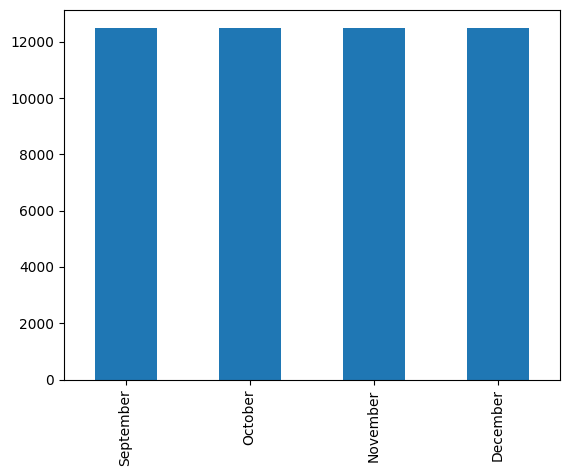

In [55]:
df['Month'].value_counts().plot(kind='bar')

In [56]:
df['Occupation'].value_counts()

Lawyer           3556
Architect        3436
Mechanic         3423
Engineer         3411
Accountant       3371
Developer        3365
Media_Manager    3356
Scientist        3352
Entrepreneur     3334
Teacher          3322
Journalist       3250
Doctor           3244
Manager          3234
Musician         3188
Writer           3158
Name: Occupation, dtype: int64

<Axes: >

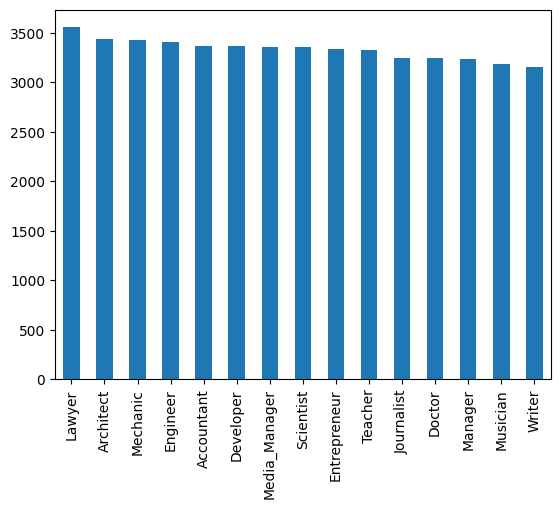

In [57]:
df['Occupation'].value_counts().plot(kind='bar')

In [58]:
#df['Payment_Behaviour'].value_counts()

# **Check Outliers**

**apply Z-score for:** Normal Distribution

**apply Interquartile-rules for:** Skew Distribution

**apply Percentile-base(Winsorizing) approche for:** Others Distribution

**using domain knowledge apply:** Box-Cox Transformation and Robust Scaling and log-transformations

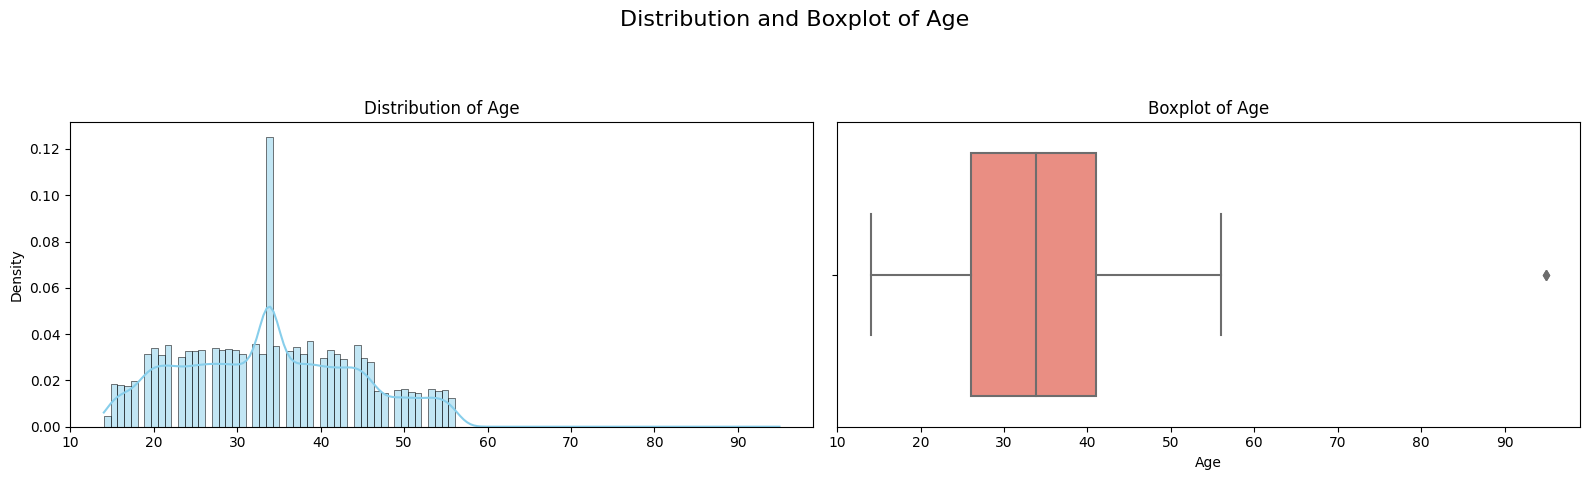

In [59]:
# Visualize 'Age'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Age', fontsize=16)
sns.histplot(df['Age'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel("")
sns.boxplot(x=df['Age'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Age')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


**Removing outliers from Age column**

In [60]:
upper_limit = df['Age'].mean() + 3 * df['Age'].std()
lower_limit = df['Age'].mean() - 3 * df['Age'].std()

#apply z-score

df['Age'] = np.where(
   df.Age > upper_limit,
   upper_limit,
   np.where(
       df.Age < lower_limit,
       lower_limit,
       df.Age
   )
)

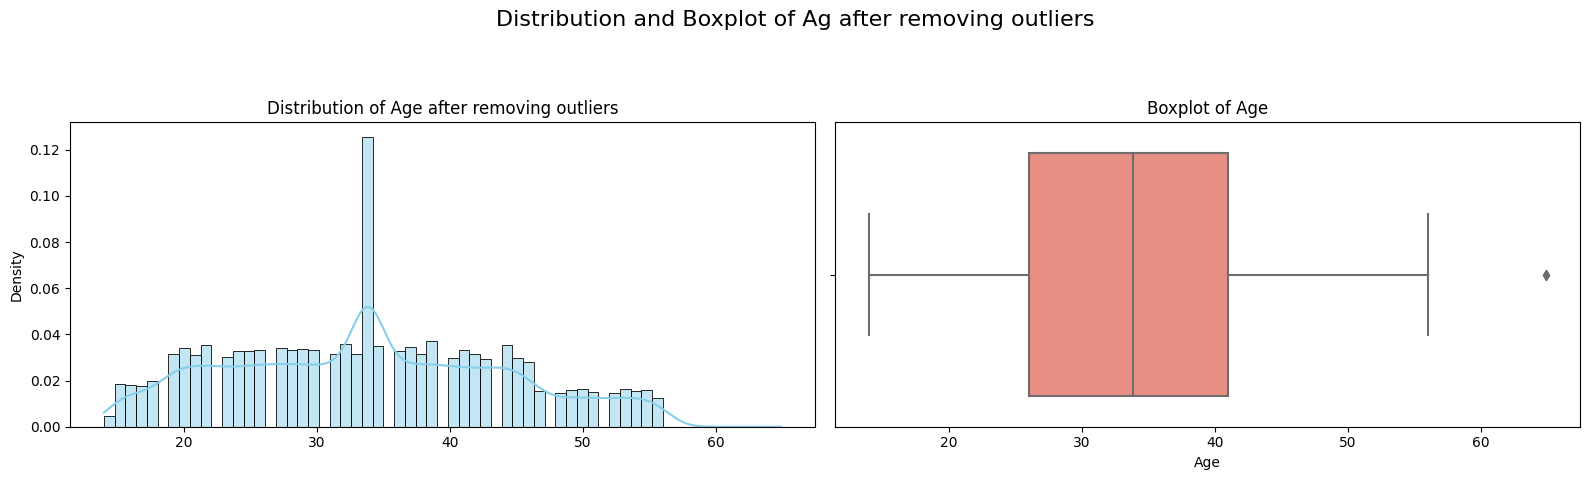

In [61]:
# Visualize 'Age'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Ag after removing outliers', fontsize=16)
sns.histplot(df['Age'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Age after removing outliers')
axes[0].set_xlabel("")
sns.boxplot(x=df['Age'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Age')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


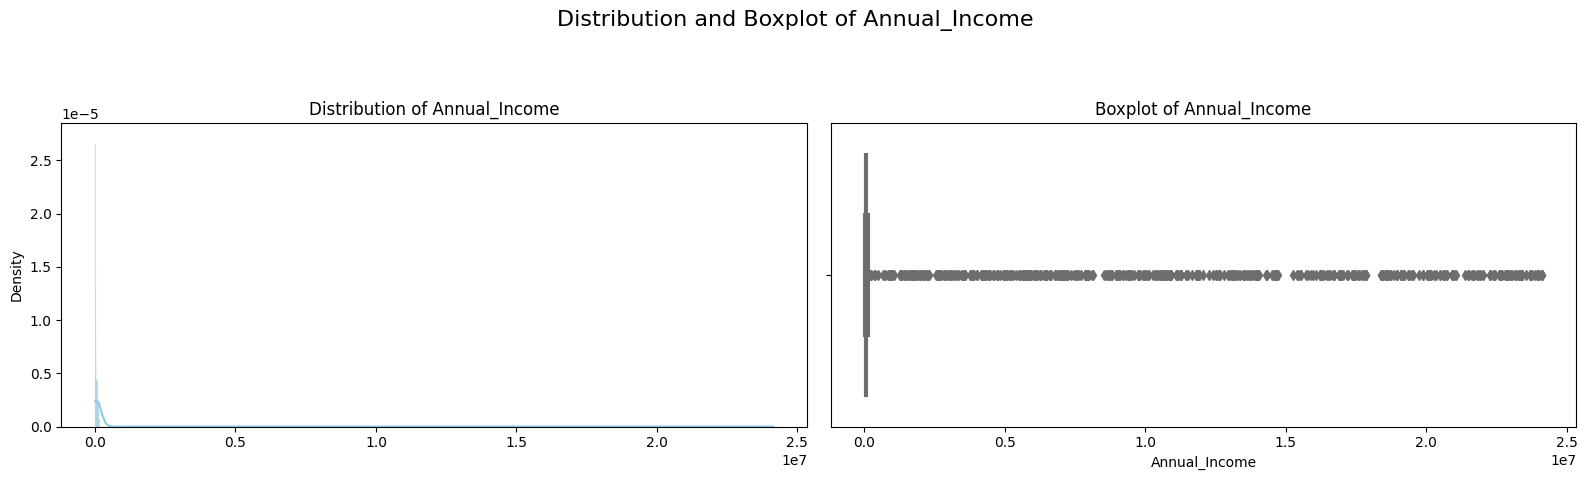

In [62]:
# Visualize 'Annual_Income'
pd.set_option('display.float_format', lambda x: '%.3f' % x)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Annual_Income', fontsize=16)
sns.histplot(df['Annual_Income'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Annual_Income')
axes[0].set_xlabel("")
sns.boxplot(x=df['Annual_Income'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Annual_Income')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


**Removing Outliers from Annual Income column**

In [63]:
upper_limit = df.Annual_Income.quantile(0.99)
lower_limit = df.Annual_Income.quantile(0.01)

#apply percentile

df['Annual_Income'] = np.where(
        df.Annual_Income >= upper_limit,
        upper_limit,
        np.where(df.Annual_Income <= lower_limit,
        lower_limit,
        df.Annual_Income)
        )

In [64]:
df['Annual_Income'] = np.log1p(df['Annual_Income']) #apply log-transformations

In [65]:
df.Annual_Income.describe()

count   50000.000
mean       10.655
std         0.858
min         8.933
25%         9.907
50%        10.622
75%        11.333
max        12.096
Name: Annual_Income, dtype: float64

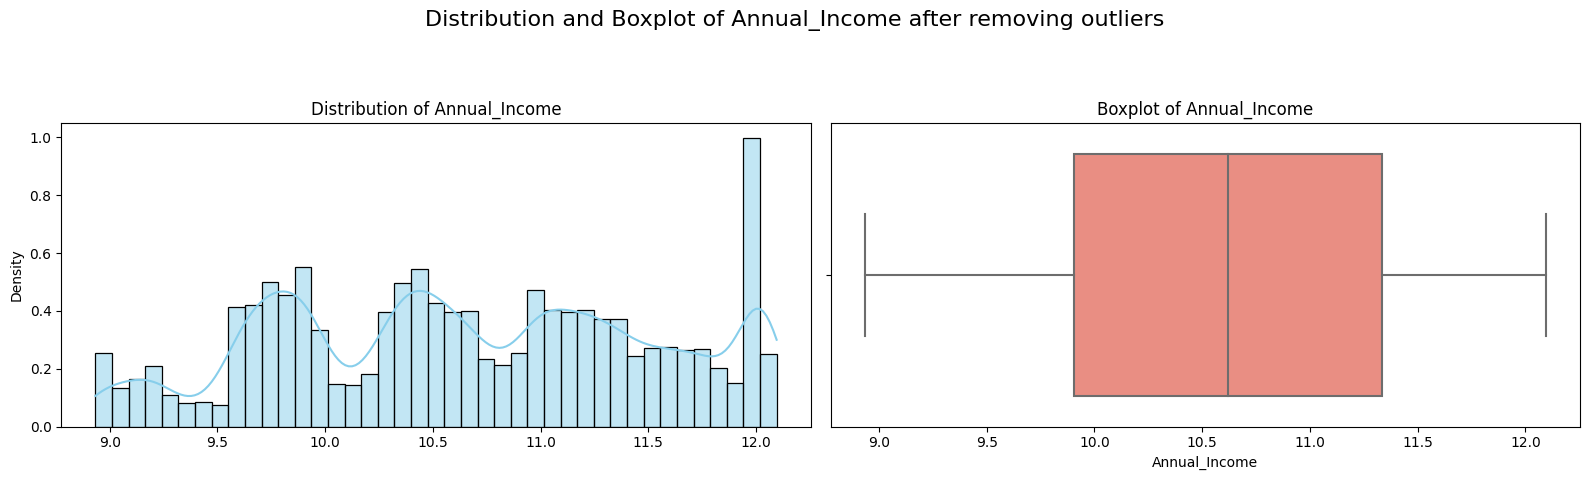

In [66]:
# Visualize 'Annual_Income'
pd.set_option('display.float_format', lambda x: '%.3f' % x)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Annual_Income after removing outliers', fontsize=16)
sns.histplot(df['Annual_Income'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Annual_Income')
axes[0].set_xlabel("")
sns.boxplot(x=df['Annual_Income'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Annual_Income')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


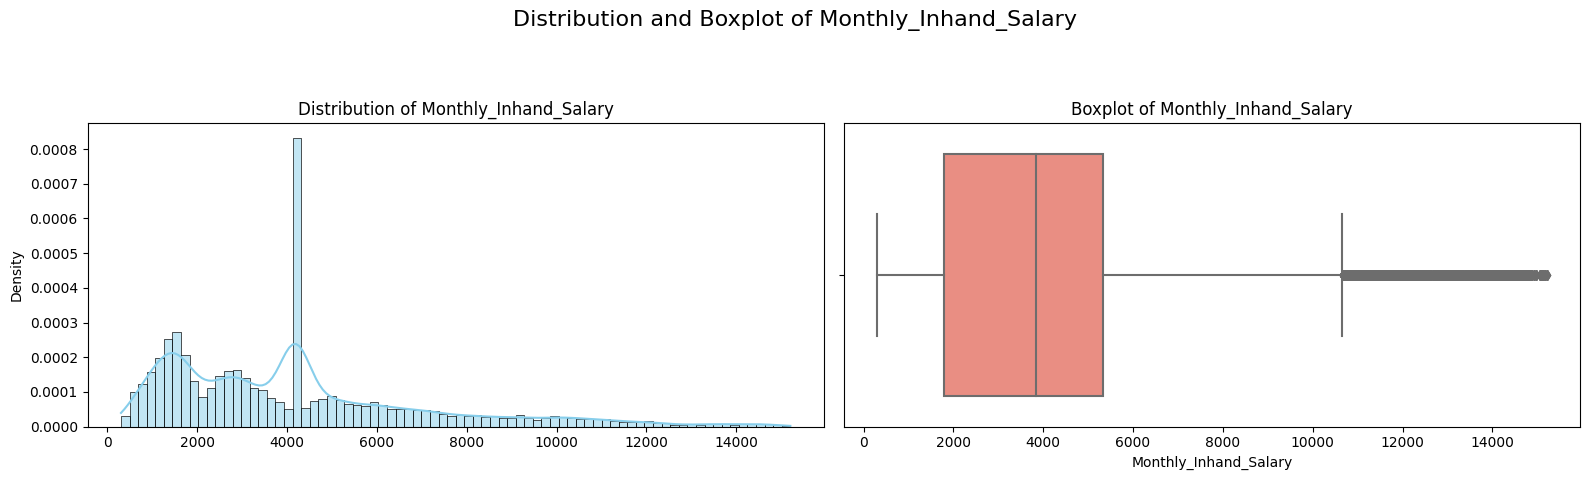

In [67]:
# Visualize 'Monthly_Inhand_Salary'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Monthly_Inhand_Salary', fontsize=16)
sns.histplot(df['Monthly_Inhand_Salary'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Monthly_Inhand_Salary')
axes[0].set_xlabel("")
sns.boxplot(x=df['Monthly_Inhand_Salary'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Monthly_Inhand_Salary')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


**Removing outliers from Monthly_Inhand_Salary using Interquadile**

In [68]:
percentile25 = df.Monthly_Inhand_Salary.quantile(0.25)
percentile75 = df.Monthly_Inhand_Salary.quantile(0.75)

#apply Interquartile

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

df['Monthly_Inhand_Salary'] = np.where(
    df.Monthly_Inhand_Salary > upper_limit,
    upper_limit,
    np.where(
        df.Monthly_Inhand_Salary < lower_limit,
        lower_limit,
        df.Monthly_Inhand_Salary
    )
)

In [69]:
df.Monthly_Inhand_Salary.describe()

count   50000.000
mean     4107.302
std      2718.816
min       303.645
25%      1794.304
50%      3848.682
75%      5338.968
max     10655.963
Name: Monthly_Inhand_Salary, dtype: float64

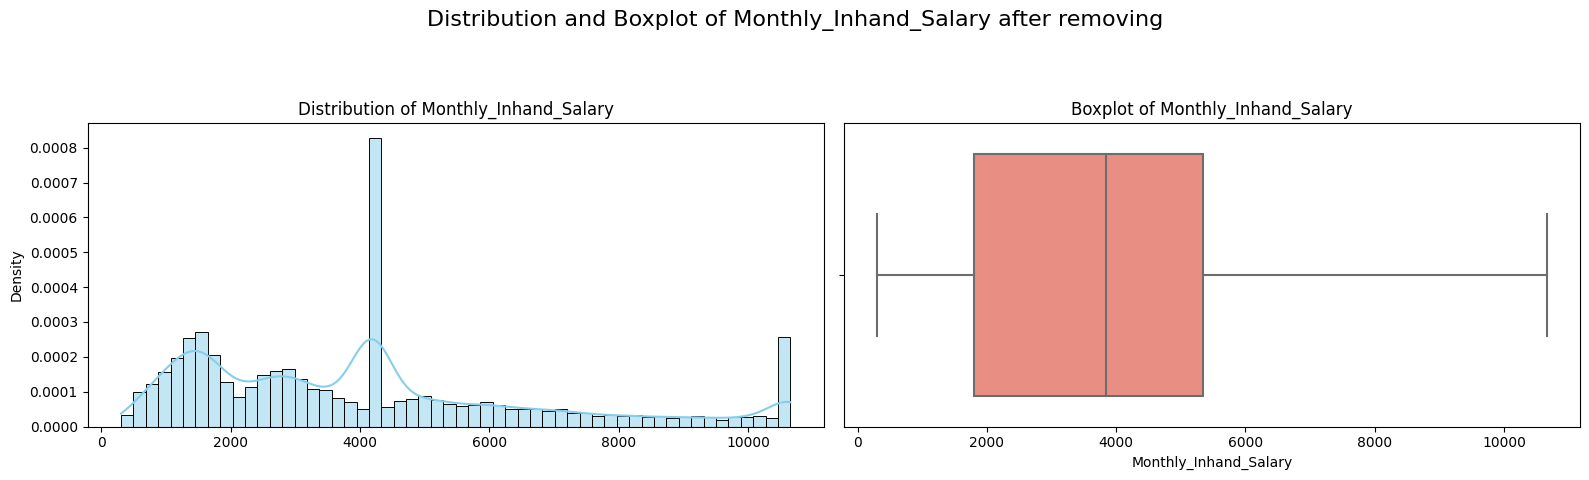

In [70]:
# Visualize 'Monthly_Inhand_Salary'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Monthly_Inhand_Salary after removing', fontsize=16)
sns.histplot(df['Monthly_Inhand_Salary'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Monthly_Inhand_Salary')
axes[0].set_xlabel("")
sns.boxplot(x=df['Monthly_Inhand_Salary'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Monthly_Inhand_Salary')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

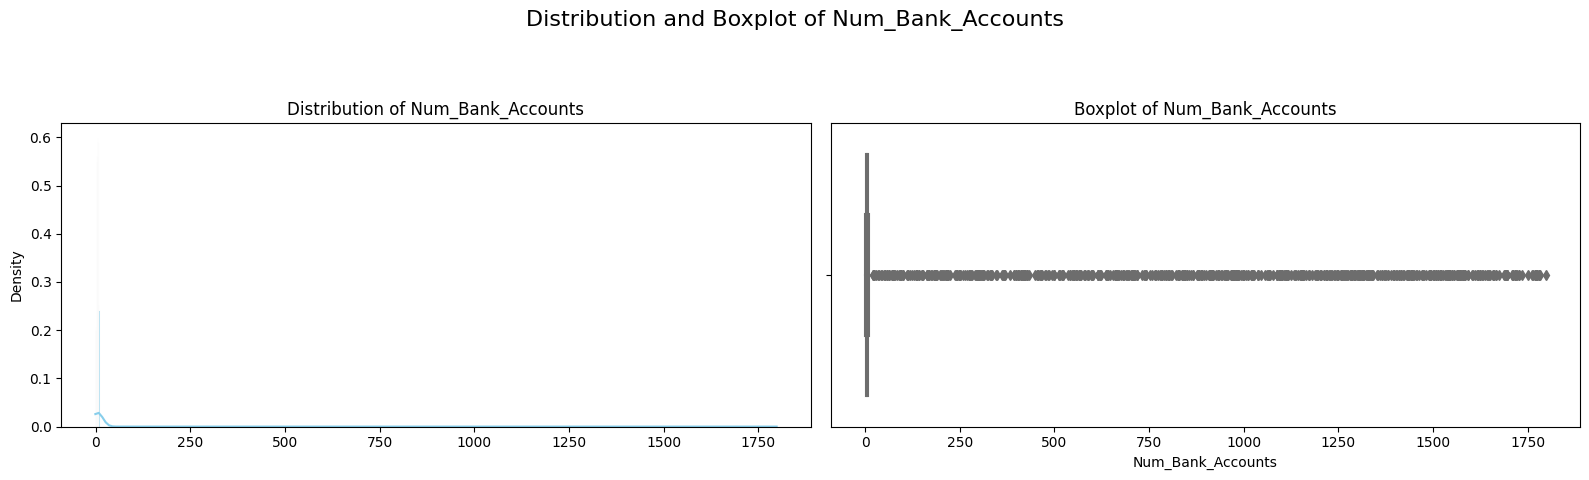

In [71]:
# Visualize 'Num_Bank_Accounts'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_Bank_Accounts', fontsize=16)
sns.histplot(df['Num_Bank_Accounts'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_Bank_Accounts')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_Bank_Accounts'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_Bank_Accounts')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


**Apply log Transformer**

In [72]:


#removing negative values
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'] + abs(df['Num_Bank_Accounts'].min()) + 1

df.Num_Bank_Accounts.describe()

count   50000.000
mean       18.838
std       116.397
min         1.000
25%         5.000
50%         8.000
75%         9.000
max      1800.000
Name: Num_Bank_Accounts, dtype: float64

In [73]:
# Apply log transformation
df['Num_Bank_Accounts'] = np.log1p(df['Num_Bank_Accounts'])

# Display summary statistics
print(df['Num_Bank_Accounts'].describe())


count   50000.000
mean        2.123
std         0.624
min         0.693
25%         1.792
50%         2.197
75%         2.303
max         7.496
Name: Num_Bank_Accounts, dtype: float64


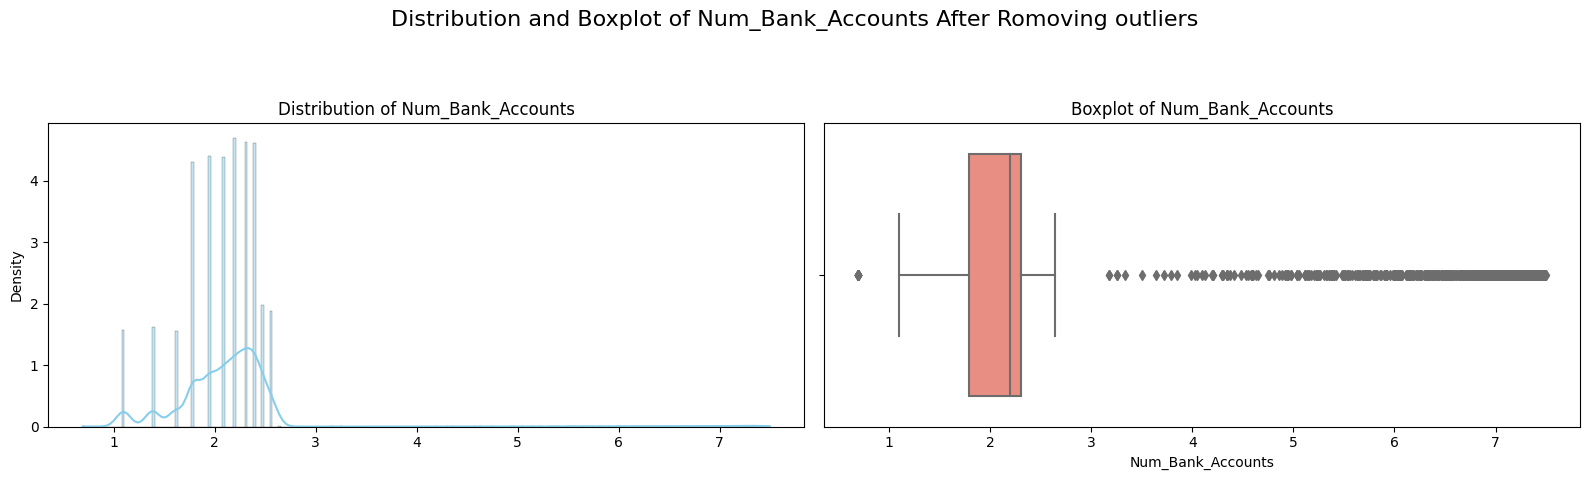

In [74]:
# Visualize 'Num_Bank_Accounts'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_Bank_Accounts After Romoving outliers', fontsize=16)
sns.histplot(df['Num_Bank_Accounts'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_Bank_Accounts')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_Bank_Accounts'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_Bank_Accounts')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

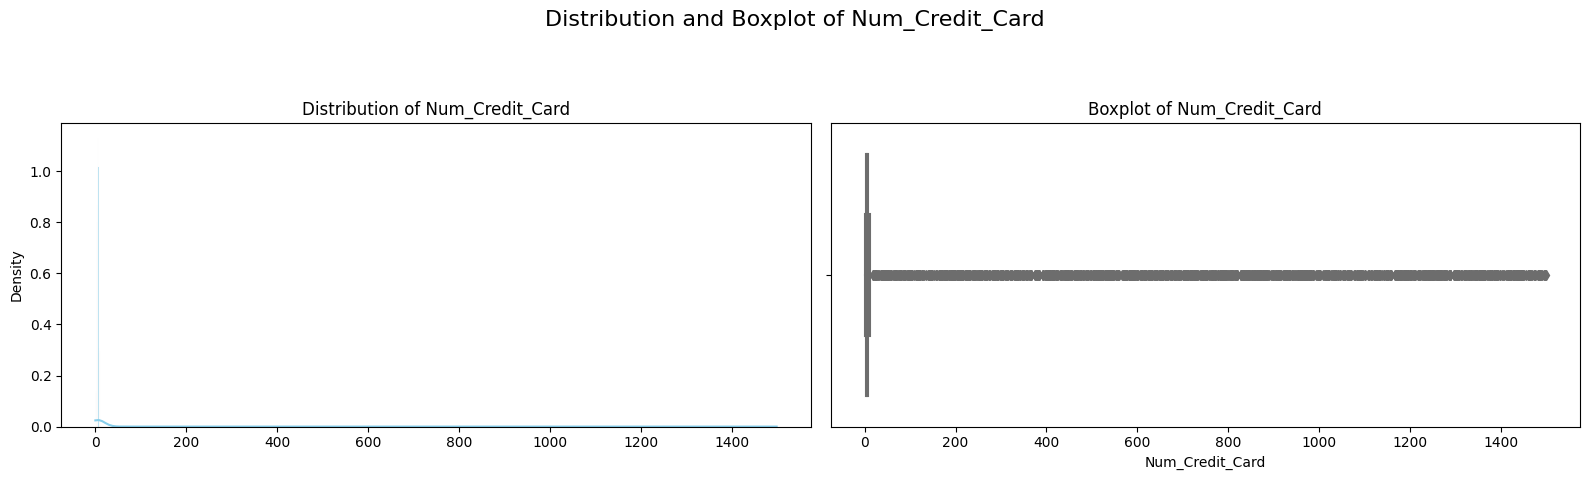

In [75]:
# Visualize 'Num_Credit_Card'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_Credit_Card', fontsize=16)
sns.histplot(df['Num_Credit_Card'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_Credit_Card')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_Credit_Card'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_Credit_Card')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


**Num_Credit_Card for this column I don't understand it's distribution that's why I'm using Box-Cox transformation**

In [76]:
#removing negative values
df['Num_Credit_Card'] = df['Num_Credit_Card'] + abs(df['Num_Credit_Card'].min()) + 1
df['Num_Bank_Accounts'] = np.log1p(df['Num_Bank_Accounts'])

df.Num_Credit_Card.describe()

count   50000.000
mean       23.921
std       129.315
min         1.000
25%         5.000
50%         6.000
75%         8.000
max      1500.000
Name: Num_Credit_Card, dtype: float64

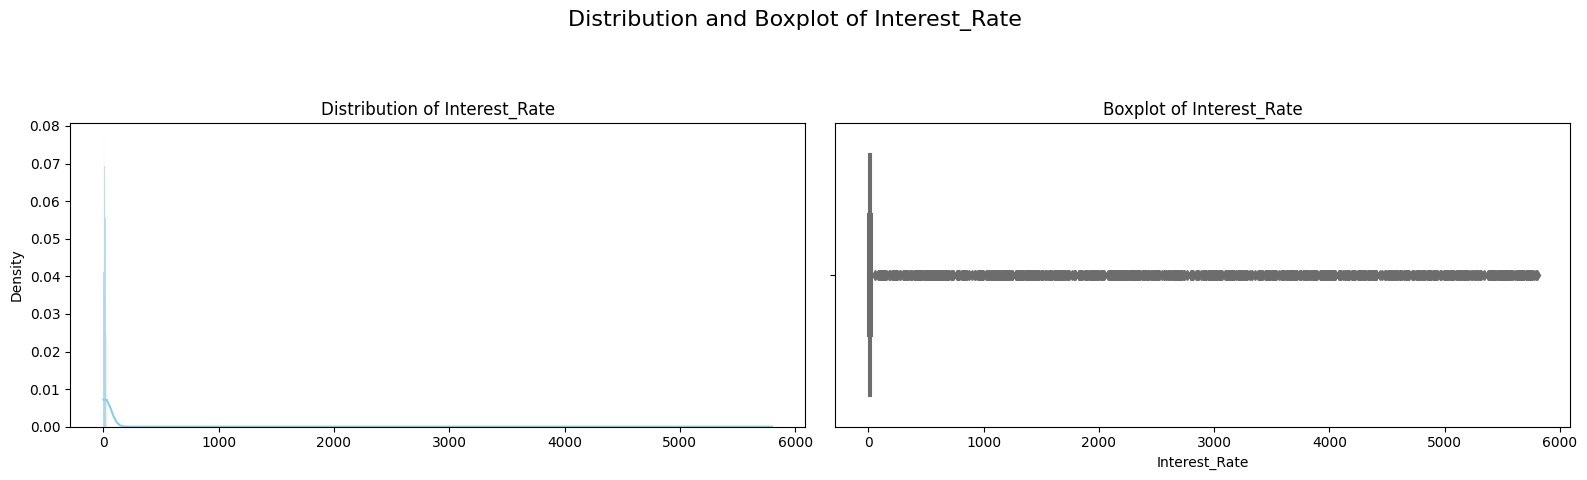

In [77]:
# Visualize 'Interest_Rate'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Interest_Rate', fontsize=16)
sns.histplot(df['Interest_Rate'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Interest_Rate')
axes[0].set_xlabel("")
sns.boxplot(x=df['Interest_Rate'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Interest_Rate')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


In [78]:
from scipy.stats import boxcox

transformed_data, lambda_value = boxcox(df['Interest_Rate'], lmbda=None)

df['Interest_Rate'] = np.power((transformed_data * lambda_value) + 1, 1 / lambda_value)

df.Interest_Rate.describe()

count   50000.000
mean       68.773
std       451.602
min         1.000
25%         8.000
50%        13.000
75%        20.000
max      5799.000
Name: Interest_Rate, dtype: float64

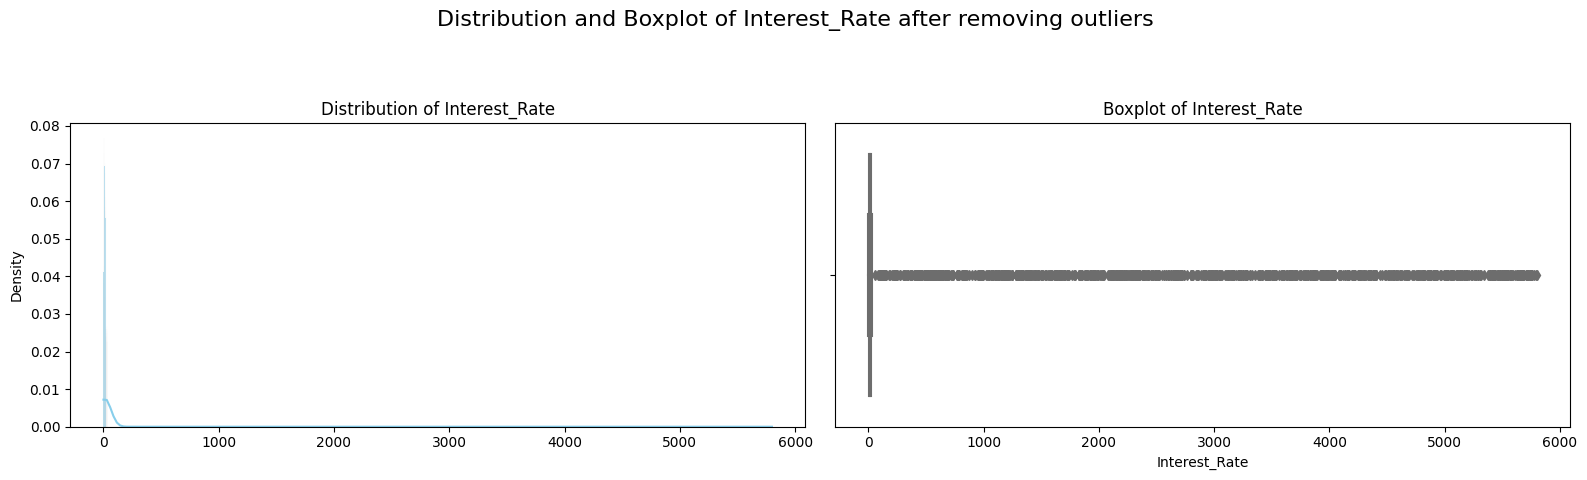

In [79]:
# Visualize 'Interest_Rate'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Interest_Rate after removing outliers', fontsize=16)
sns.histplot(df['Interest_Rate'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Interest_Rate')
axes[0].set_xlabel("")
sns.boxplot(x=df['Interest_Rate'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Interest_Rate')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

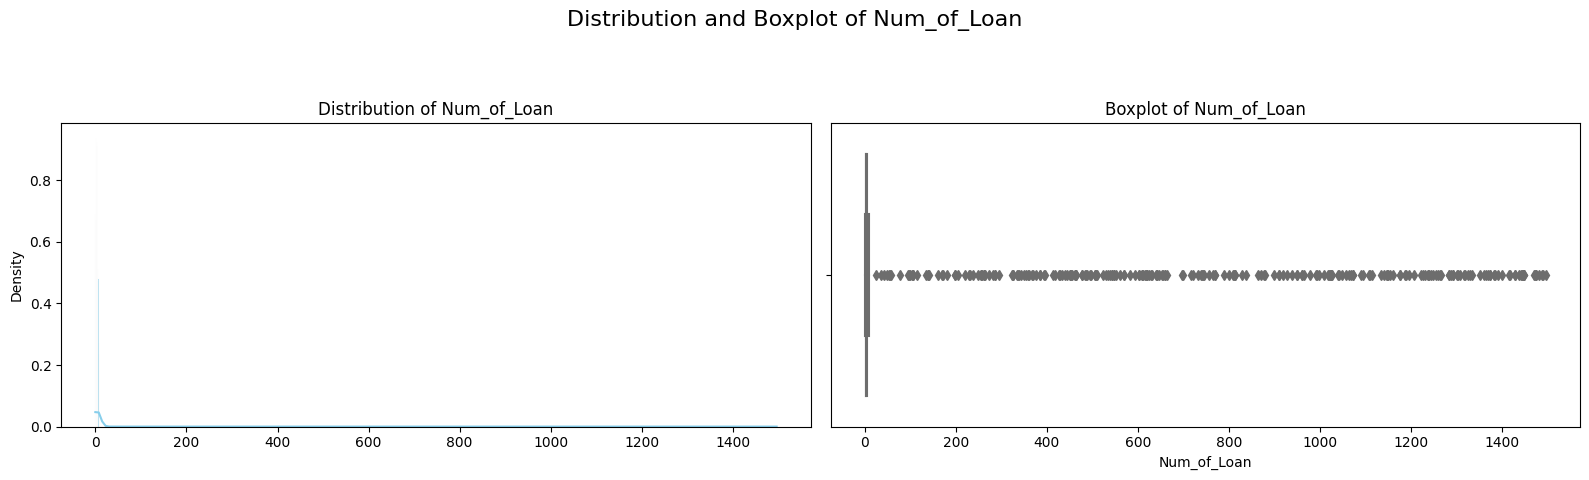

In [80]:
# Visualize 'Num_of_Loan'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_of_Loan', fontsize=16)
sns.histplot(df['Num_of_Loan'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_of_Loan')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_of_Loan'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_of_Loan')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


In [81]:
#removing negative values
df['Num_of_Loan'] = df['Num_of_Loan'] + abs(df['Num_of_Loan'].min()) + 1

df['Num_of_Loan'] = np.log1p(df['Num_of_Loan'])

df.Num_of_Loan.describe()

count   50000.000
mean        1.640
std         0.595
min         0.693
25%         1.386
50%         1.609
75%         1.946
max         7.312
Name: Num_of_Loan, dtype: float64

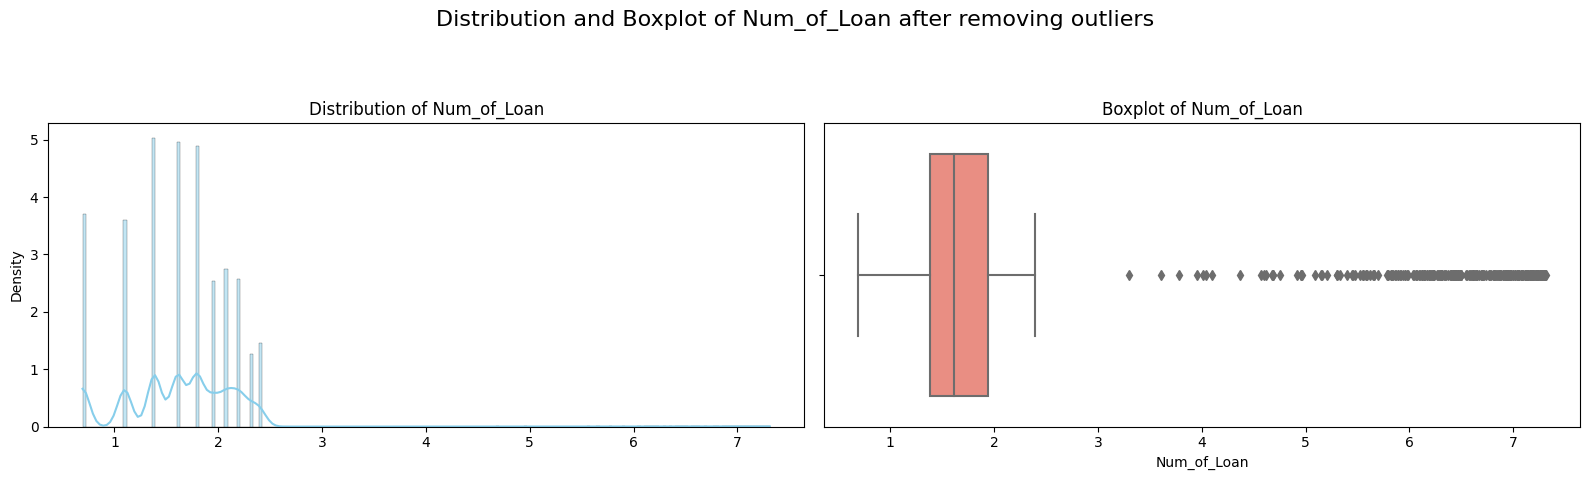

In [82]:
# Visualize 'Num_of_Loan'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_of_Loan after removing outliers', fontsize=16)
sns.histplot(df['Num_of_Loan'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_of_Loan')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_of_Loan'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_of_Loan')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

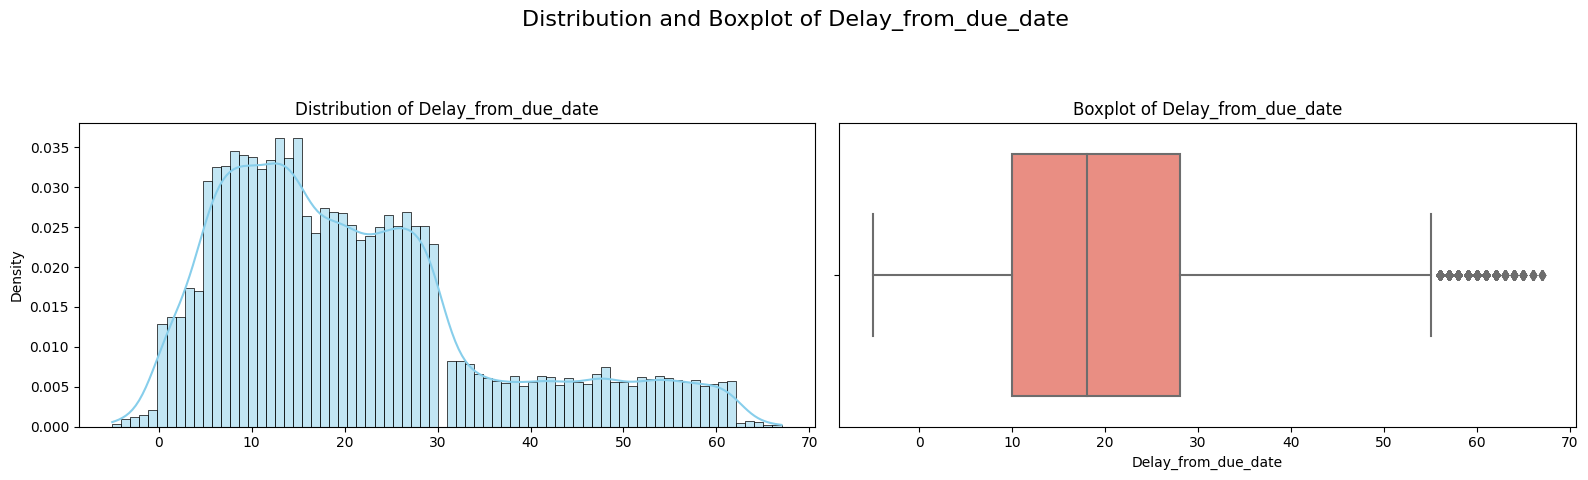

In [83]:
# Visualize 'Delay_from_due_date'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Delay_from_due_date', fontsize=16)
sns.histplot(df['Delay_from_due_date'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Delay_from_due_date')
axes[0].set_xlabel("")
sns.boxplot(x=df['Delay_from_due_date'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Delay_from_due_date')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


**Removing outliers from Delay_from_due_date column**

In [84]:
percentile25 = df.Delay_from_due_date.quantile(0.25)
percentile75 = df.Delay_from_due_date.quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

df['Delay_from_due_date'] = np.where(
    df.Delay_from_due_date > upper_limit,
    upper_limit,
    np.where(
        df.Delay_from_due_date < lower_limit,
        lower_limit,
        df.Delay_from_due_date
    )
)

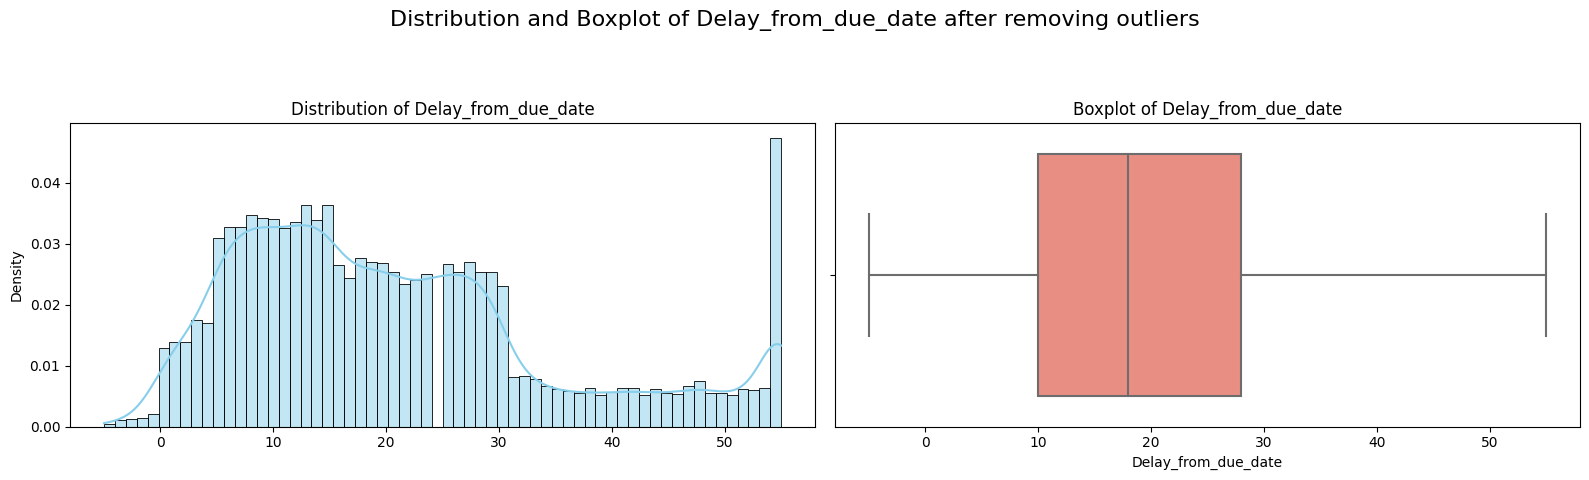

In [85]:
# Visualize 'Delay_from_due_date'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Delay_from_due_date after removing outliers', fontsize=16)
sns.histplot(df['Delay_from_due_date'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Delay_from_due_date')
axes[0].set_xlabel("")
sns.boxplot(x=df['Delay_from_due_date'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Delay_from_due_date')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


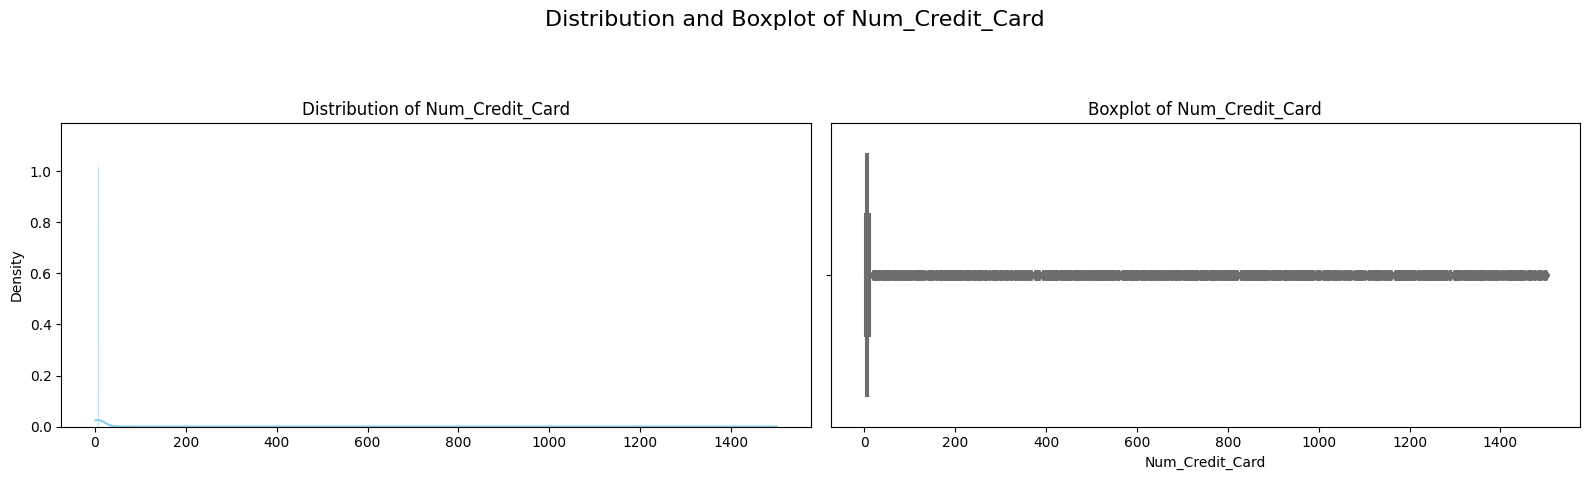

In [86]:
# Visualize 'Num_Credit_Card'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_Credit_Card', fontsize=16)
sns.histplot(df['Num_Credit_Card'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_Credit_Card')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_Credit_Card'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_Credit_Card')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


In [87]:
df['Num_Credit_Card'] = np.log1p(df['Num_Credit_Card'])

df.Num_Credit_Card.describe()

count   50000.000
mean        2.082
std         0.735
min         0.693
25%         1.792
50%         1.946
75%         2.197
max         7.314
Name: Num_Credit_Card, dtype: float64

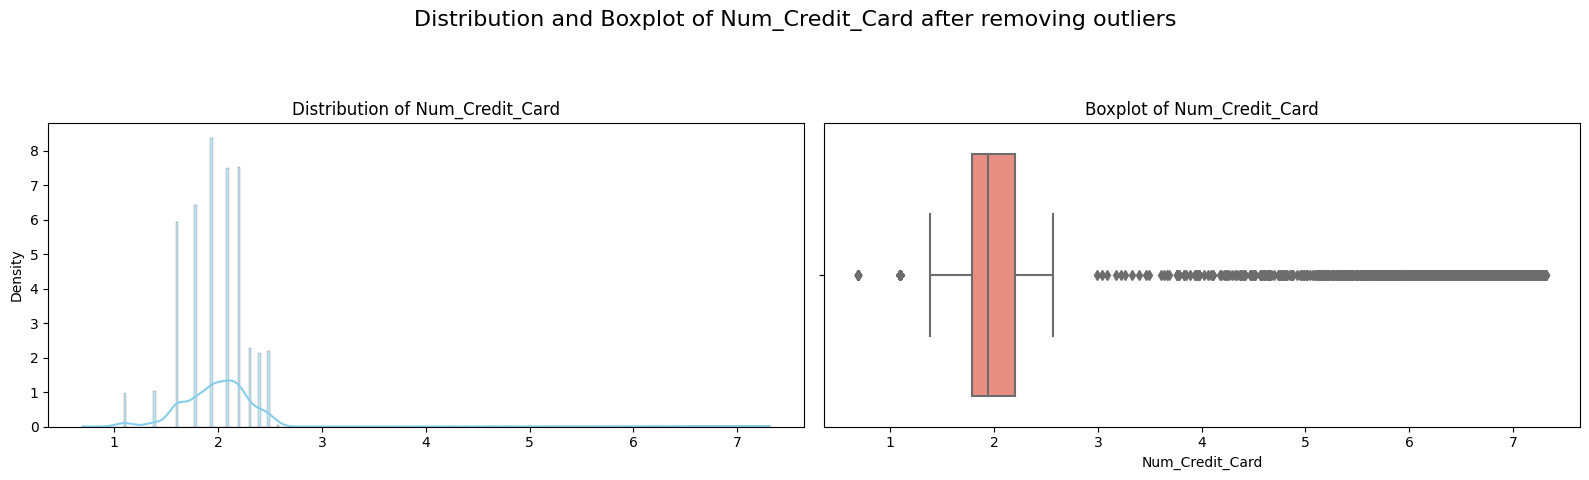

In [88]:
# Visualize 'Num_Credit_Card'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_Credit_Card after removing outliers', fontsize=16)
sns.histplot(df['Num_Credit_Card'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_Credit_Card')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_Credit_Card'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_Credit_Card')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


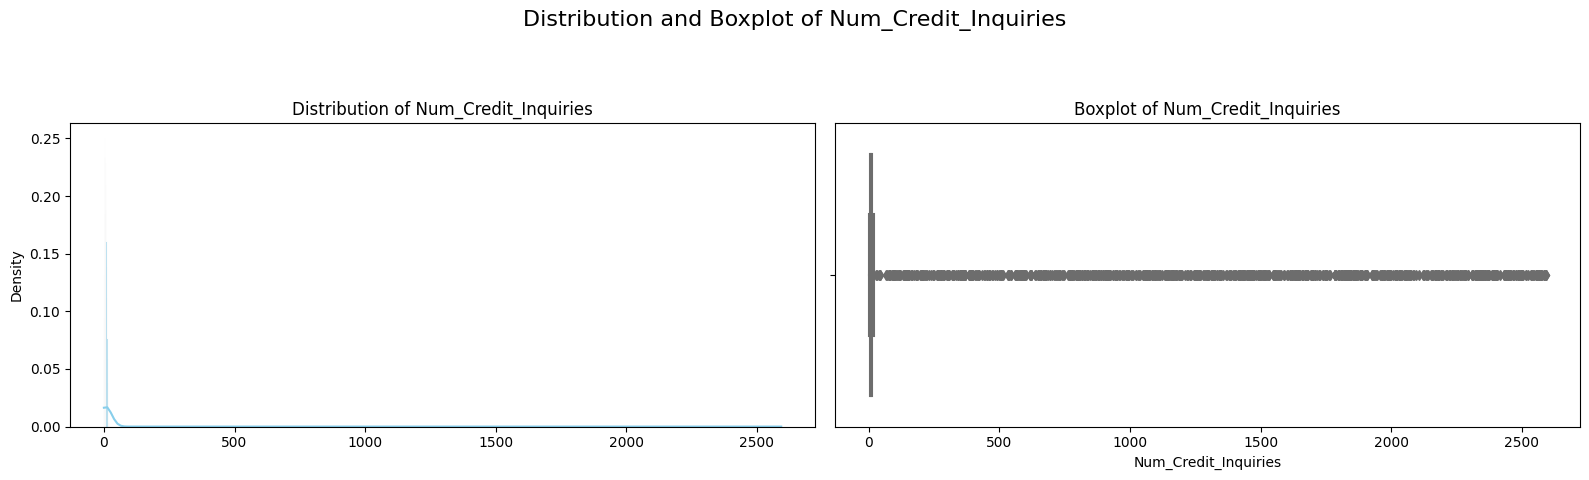

In [89]:
# Visualize 'Num_Credit_Inquiries'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_Credit_Inquiries', fontsize=16)
sns.histplot(df['Num_Credit_Inquiries'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_Credit_Inquiries')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_Credit_Inquiries'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_Credit_Inquiries')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


In [90]:
from scipy.stats import boxcox

#removing negative values
df['Num_Credit_Inquiries'] = df['Num_Credit_Inquiries'] + abs(df['Num_Credit_Inquiries'].min()) + 1

transformed_data, lambda_value = boxcox(df['Num_Credit_Inquiries'], lmbda=None)

df['Num_Credit_Inquiries'] = np.power((transformed_data * lambda_value) + 1, 1 / lambda_value)


df.Num_Credit_Inquiries.describe()

count   50000.000
mean       30.685
std       194.955
min         1.000
25%         5.000
50%         8.000
75%        12.000
max      2594.000
Name: Num_Credit_Inquiries, dtype: float64

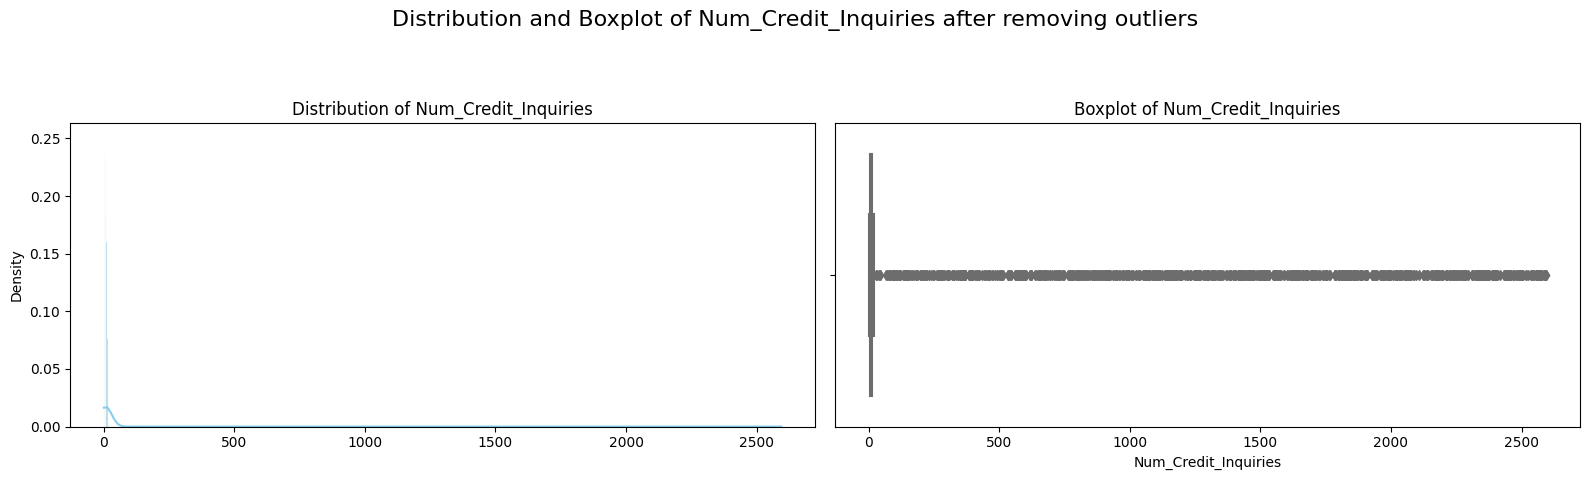

In [91]:
# Visualize 'Num_Credit_Inquiries'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Num_Credit_Inquiries after removing outliers', fontsize=16)
sns.histplot(df['Num_Credit_Inquiries'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Num_Credit_Inquiries')
axes[0].set_xlabel("")
sns.boxplot(x=df['Num_Credit_Inquiries'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Num_Credit_Inquiries')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


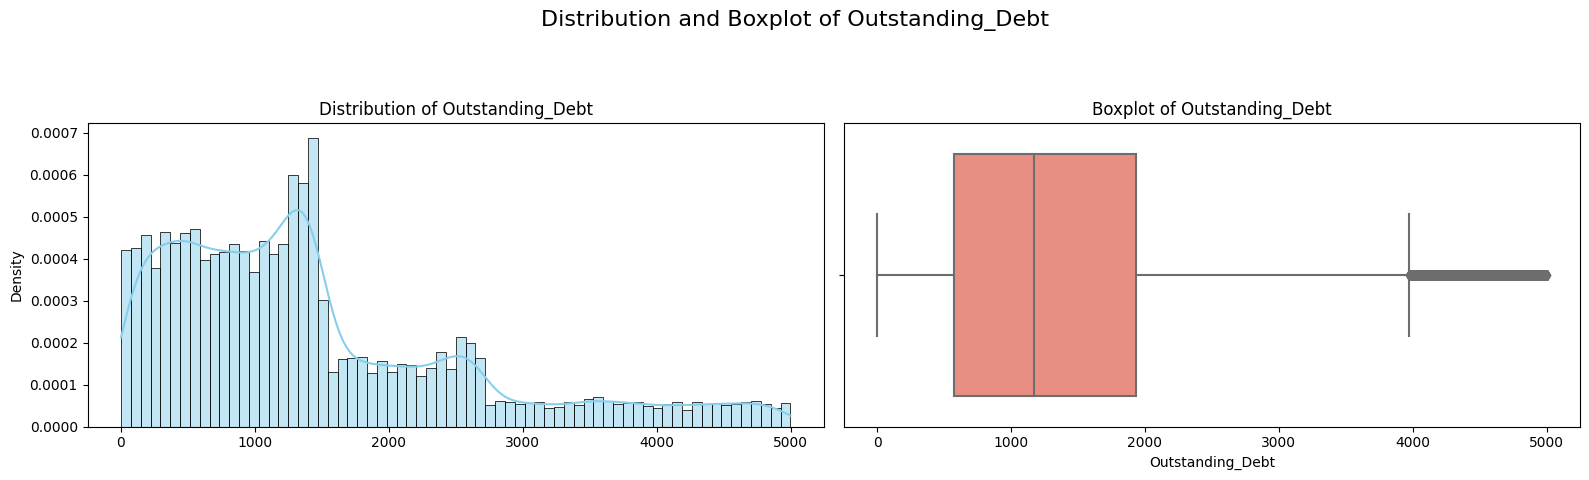

In [92]:
# Visualize 'Outstanding_Debt'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Outstanding_Debt', fontsize=16)
sns.histplot(df['Outstanding_Debt'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Outstanding_Debt')
axes[0].set_xlabel("")
sns.boxplot(x=df['Outstanding_Debt'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Outstanding_Debt')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

**Removing outliers from Outstanding_Debt column**

In [93]:
percentile25 = df.Outstanding_Debt.quantile(0.25)
percentile75 = df.Outstanding_Debt.quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

df['Delay_from_due_date'] = np.where(
    df.Outstanding_Debt > upper_limit,
    upper_limit,
    np.where(
        df.Outstanding_Debt < lower_limit,
        lower_limit,
        df.Outstanding_Debt
    )
)

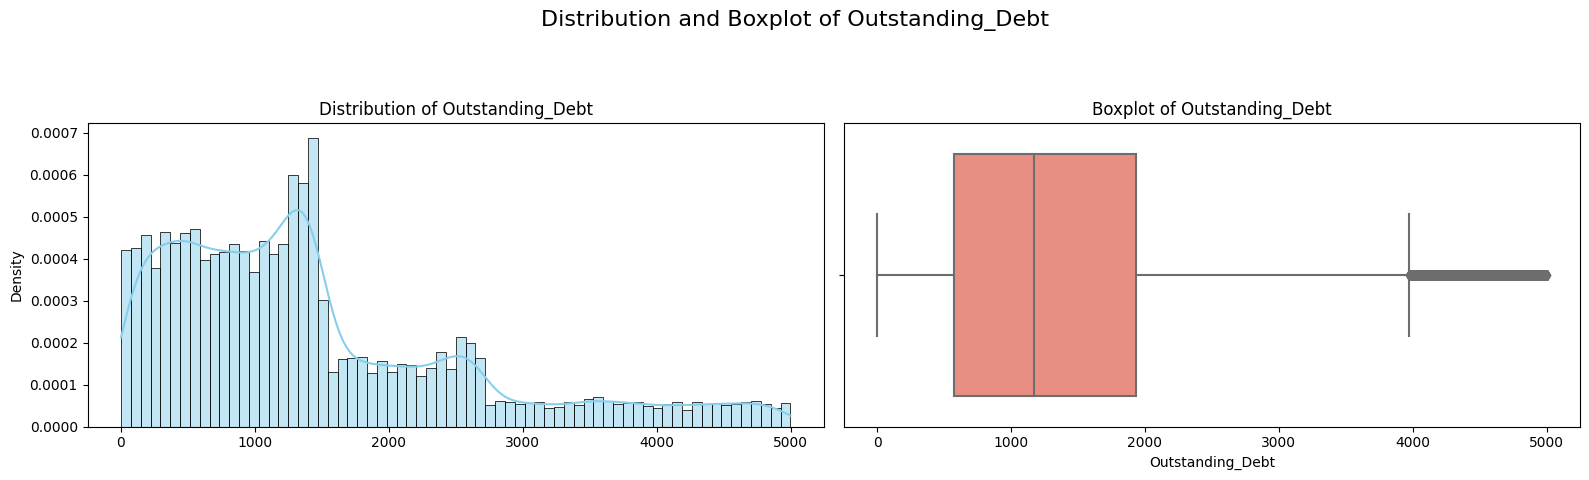

In [94]:
# Visualize 'Outstanding_Debt'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Outstanding_Debt', fontsize=16)
sns.histplot(df['Outstanding_Debt'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Outstanding_Debt')
axes[0].set_xlabel("")
sns.boxplot(x=df['Outstanding_Debt'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Outstanding_Debt')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

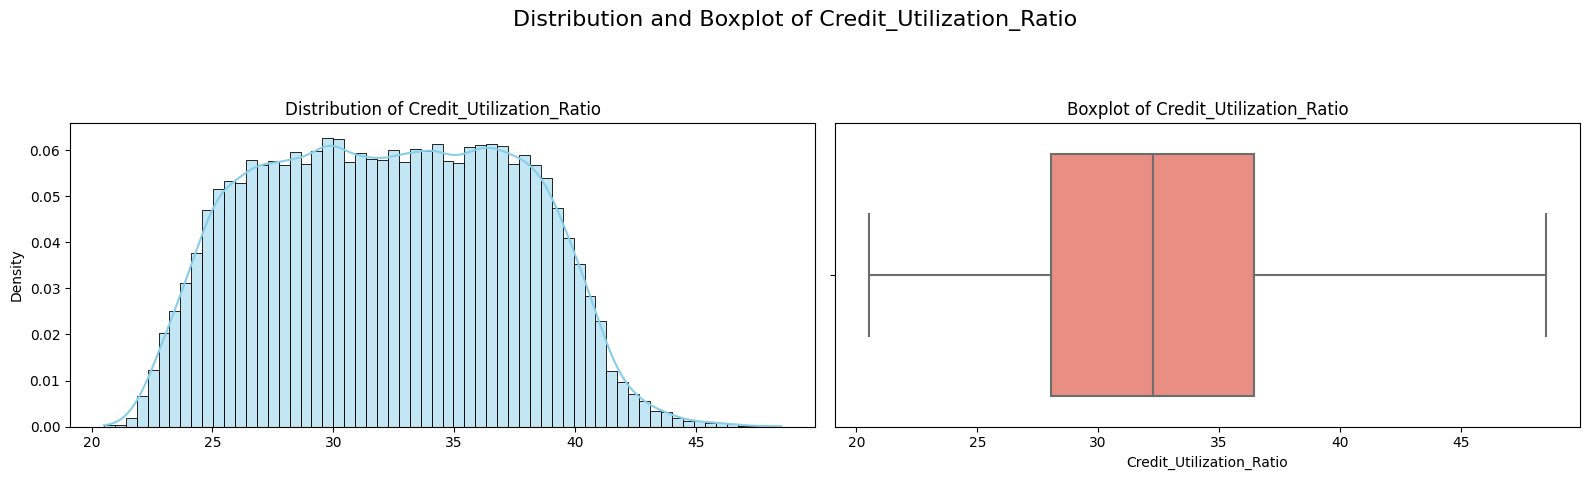

In [95]:
# Visualize 'Credit_Utilization_Ratio'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Credit_Utilization_Ratio', fontsize=16)
sns.histplot(df['Credit_Utilization_Ratio'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Credit_Utilization_Ratio')
axes[0].set_xlabel("")
sns.boxplot(x=df['Credit_Utilization_Ratio'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Credit_Utilization_Ratio')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

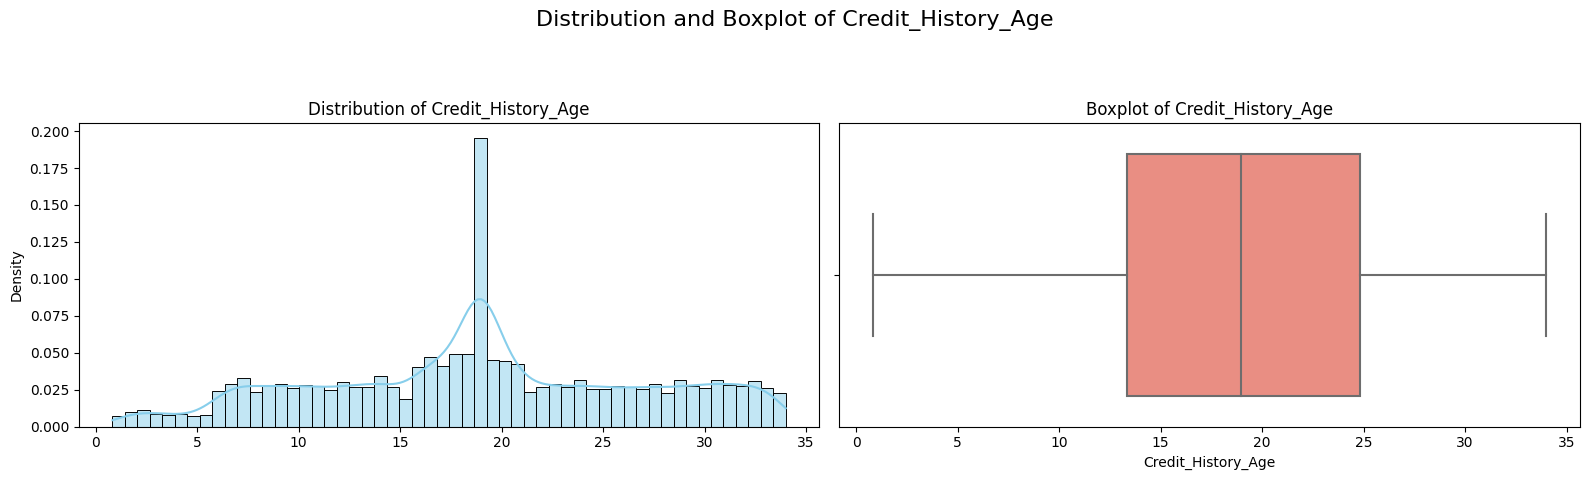

In [96]:
# Visualize 'Credit_History_Age'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Credit_History_Age', fontsize=16)
sns.histplot(df['Credit_History_Age'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Credit_History_Age')
axes[0].set_xlabel("")
sns.boxplot(x=df['Credit_History_Age'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Credit_History_Age')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

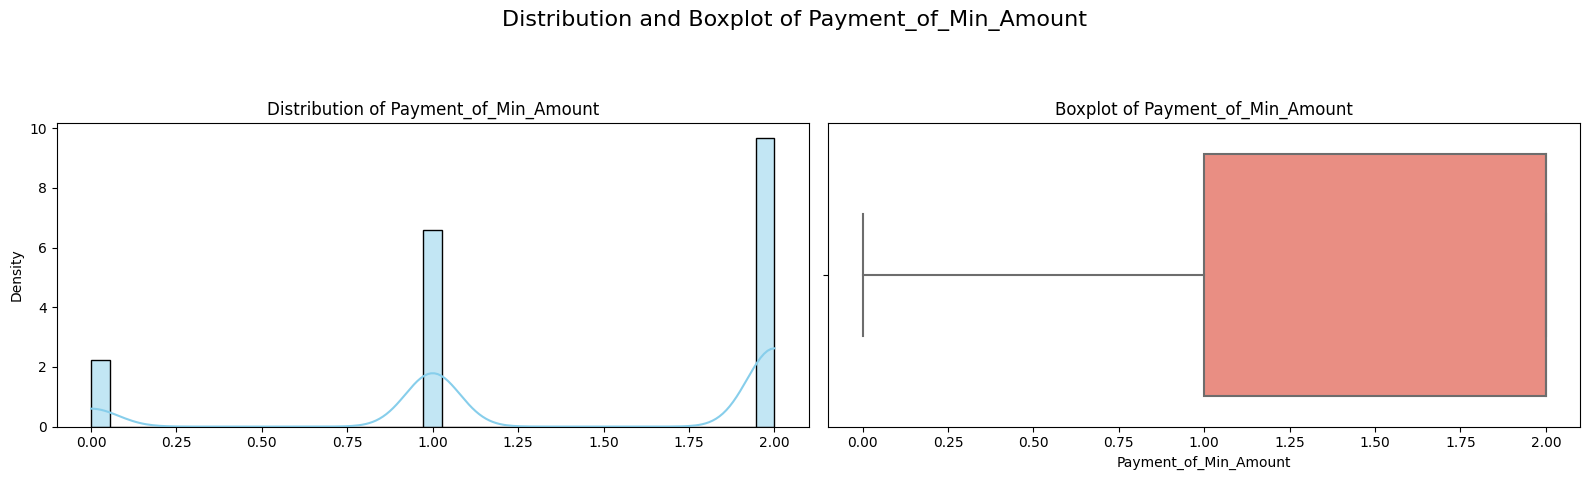

In [97]:
# Visualize 'Payment_of_Min_Amount'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Payment_of_Min_Amount', fontsize=16)
sns.histplot(df['Payment_of_Min_Amount'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Payment_of_Min_Amount')
axes[0].set_xlabel("")
sns.boxplot(x=df['Payment_of_Min_Amount'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Payment_of_Min_Amount')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

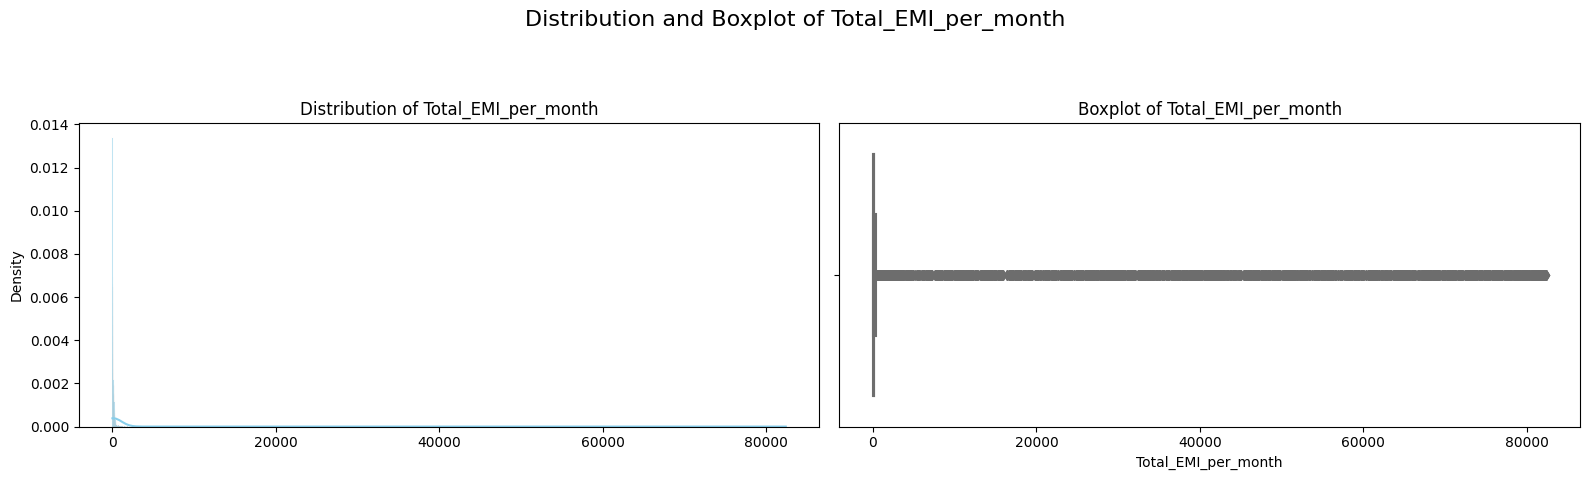

In [98]:
# Visualize 'Total_EMI_per_month'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Total_EMI_per_month', fontsize=16)
sns.histplot(df['Total_EMI_per_month'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Total_EMI_per_month')
axes[0].set_xlabel("")
sns.boxplot(x=df['Total_EMI_per_month'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Total_EMI_per_month')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

In [99]:
df['Total_EMI_per_month'] = np.log1p(df['Total_EMI_per_month'])

df.Total_EMI_per_month.describe()

count   50000.000
mean        4.207
std         1.980
min         0.000
25%         3.503
50%         4.327
75%         5.177
max        11.319
Name: Total_EMI_per_month, dtype: float64

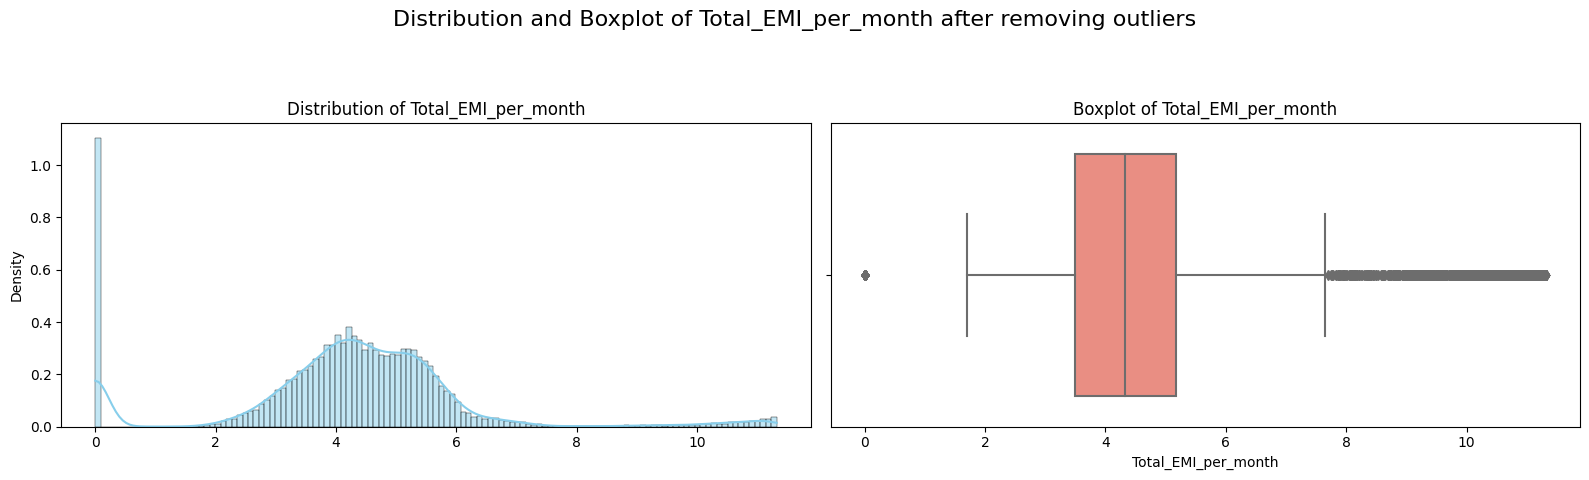

In [100]:
# Visualize 'Total_EMI_per_month'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Total_EMI_per_month after removing outliers', fontsize=16)
sns.histplot(df['Total_EMI_per_month'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Total_EMI_per_month')
axes[0].set_xlabel("")
sns.boxplot(x=df['Total_EMI_per_month'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Total_EMI_per_month')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

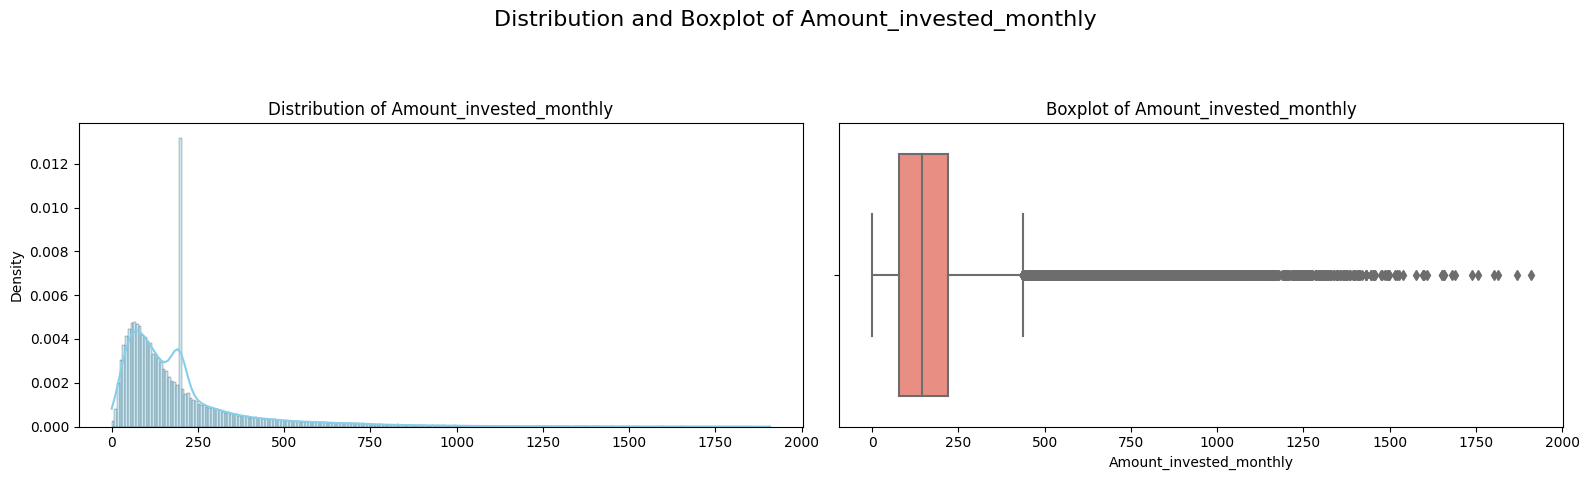

In [101]:
# Visualize 'Amount_invested_monthly'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Amount_invested_monthly', fontsize=16)
sns.histplot(df['Amount_invested_monthly'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Amount_invested_monthly')
axes[0].set_xlabel("")
sns.boxplot(x=df['Amount_invested_monthly'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Amount_invested_monthly')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

In [102]:
percentile25 = df.Amount_invested_monthly.quantile(0.25)
percentile75 = df.Amount_invested_monthly.quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

df['Amount_invested_monthly'] = np.where(
    df.Amount_invested_monthly > upper_limit,
    upper_limit,
    np.where(
        df.Amount_invested_monthly < lower_limit,
        lower_limit,
        df.Amount_invested_monthly
    )
)

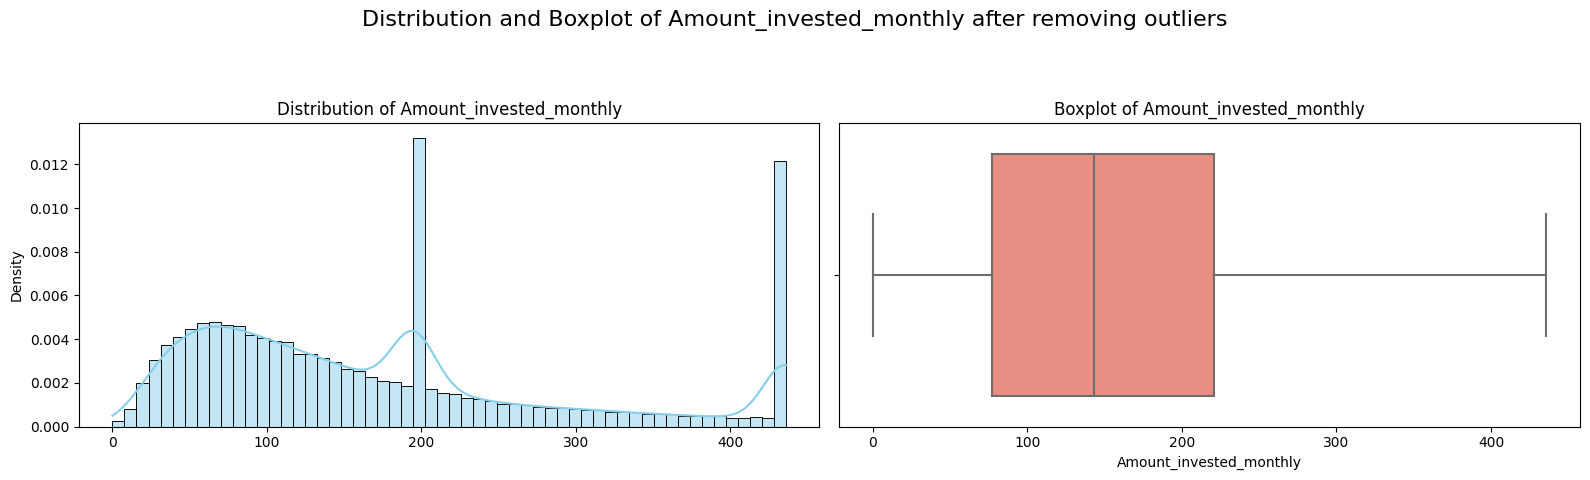

In [103]:
# Visualize 'Amount_invested_monthly'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Amount_invested_monthly after removing outliers', fontsize=16)
sns.histplot(df['Amount_invested_monthly'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Amount_invested_monthly')
axes[0].set_xlabel("")
sns.boxplot(x=df['Amount_invested_monthly'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Amount_invested_monthly')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

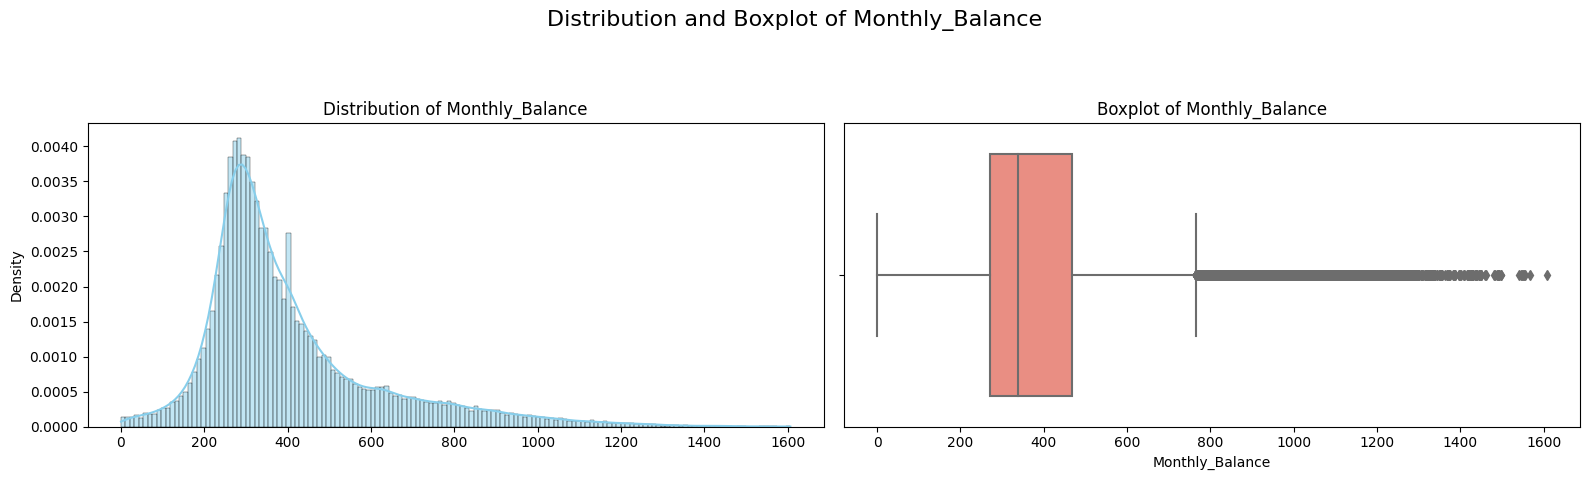

In [104]:
# Visualize 'Monthly_Balance'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Monthly_Balance', fontsize=16)
sns.histplot(df['Monthly_Balance'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Monthly_Balance')
axes[0].set_xlabel("")
sns.boxplot(x=df['Monthly_Balance'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Monthly_Balance')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

In [105]:
percentile25 = df.Monthly_Balance.quantile(0.25)
percentile75 = df.Monthly_Balance.quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

df['Monthly_Balance'] = np.where(
    df.Monthly_Balance > upper_limit,
    upper_limit,
    np.where(
        df.Monthly_Balance < lower_limit,
        lower_limit,
        df.Monthly_Balance
    )
)

df.Monthly_Balance.describe()

count   50000.000
mean      388.694
std       173.506
min         0.103
25%       271.119
50%       338.992
75%       468.571
max       764.750
Name: Monthly_Balance, dtype: float64

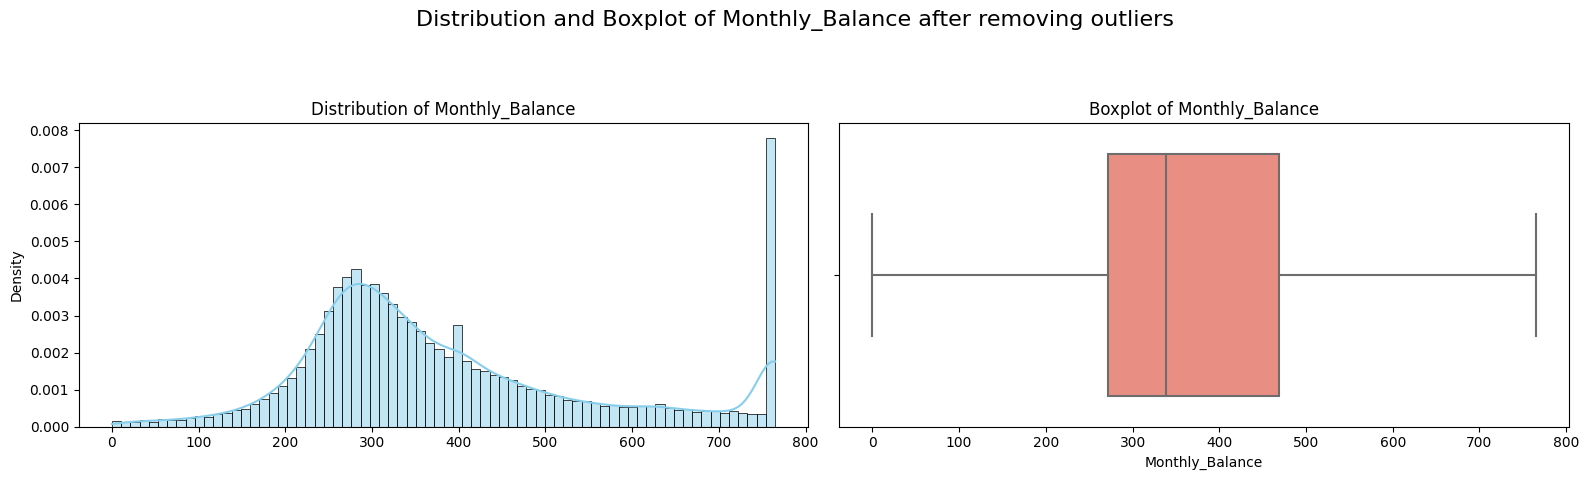

In [106]:
# Visualize 'Monthly_Balance'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribution and Boxplot of Monthly_Balance after removing outliers', fontsize=16)
sns.histplot(df['Monthly_Balance'], ax=axes[0], kde=True, color='skyblue', stat="density", common_norm=False)
axes[0].set_title('Distribution of Monthly_Balance')
axes[0].set_xlabel("")
sns.boxplot(x=df['Monthly_Balance'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Monthly_Balance')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

# **Choosing Target Variable**

"Monthly Balance" can have different meanings depending on the context, but here are the two most likely interpretations:

**1. Financial Account Balance:** This is the most common meaning. It refers to the amount of money remaining in your bank account at the end of each month. This applies to checking accounts, savings accounts, credit card accounts, or any other type of financial account.

**2. Budget Tracking:** In budgeting, "Monthly Balance" refers to the money left after paying all your bills and expenses for the month. This helps track progress towards financial goals like saving for a house or paying off debt.

In [107]:
X = df.drop('Credit_Mix', axis=1)
y = df['Credit_Mix']

In [108]:
y.value_counts()

Standard    18379
Good        12260
neutral      9805
Bad          9556
Name: Credit_Mix, dtype: int64

# **Imbalanced data Handle**

In [109]:
standard = (18379/(18379+12260+9805+9556)) *100
good = (12260/(18379+12260+9805+9556)) *100
neutral = (9805/(18379+12260+9805+9556)) *100
bad = (9556/(18379+12260+9805+9556)) *100

print('Standard {} percent of total Credit Mix'.format(standard))
print('Good {} percent of total Credit Mix'.format(good))
print('Neutral {} percent of total Credit Mix'.format(neutral))
print('Bad {} percent of total Credit Mix'.format(bad))

Standard 36.758 percent of total Credit Mix
Good 24.52 percent of total Credit Mix
Neutral 19.61 percent of total Credit Mix
Bad 19.112000000000002 percent of total Credit Mix


In [110]:
from imblearn.over_sampling import RandomOverSampler

over = RandomOverSampler(random_state=100)

X_new , y_new = over.fit_resample(X,y)

X_new.shape, y_new.shape

((73516, 20), (73516,))

In [111]:
y_new.value_counts()

Good        18379
neutral     18379
Standard    18379
Bad         18379
Name: Credit_Mix, dtype: int64

In [112]:
X_new.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,September,23.000,Scientist,9.858,1824.843,1.027,1.792,3.000,1.792,809.980,7.000,11.270,2023.000,809.980,35.030,22.750,1.000,3.923,236.643,186.267
1,October,24.000,Scientist,9.858,1824.843,1.027,1.792,3.000,1.792,809.980,9.000,13.270,5.000,809.980,33.053,22.833,1.000,3.923,21.465,361.444
2,November,24.000,Scientist,9.858,1824.843,1.027,1.792,3.000,1.792,809.980,4.000,12.270,5.000,809.980,33.812,18.938,1.000,3.923,148.234,264.675
3,December,33.820,Scientist,9.858,4182.004,1.027,1.792,3.000,1.792,809.980,5.000,11.270,5.000,809.980,32.431,23.000,1.000,3.923,39.083,343.827
4,September,28.000,Teacher,10.459,3037.987,0.959,1.792,6.000,1.099,605.030,1.000,5.420,6.000,605.030,25.927,27.250,1.000,2.987,39.684,485.298


**Apply MinMax() for Numberical Columns and oneHOt of categorical columns and then apply PCA**

In [113]:
columns_to_onehot = ['Month', 'Occupation'] #'Payment_Behaviour'

# Apply one-hot encoding to the specified columns
X_new = pd.get_dummies(X_new, columns=columns_to_onehot)
X_new.sample(10)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Month_December,Month_November,Month_October,Month_September,Occupation_Accountant,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
41738,32.000,9.619,971.158,1.162,1.792,17.000,1.946,1886.540,15.000,15.210,13.000,1886.540,36.311,19.167,2.000,3.863,46.982,293.530,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
12641,20.000,12.014,1770.714,1.271,2.485,29.000,1.946,3972.035,4.000,22.910,12.000,4440.420,25.329,1.500,2.000,4.052,38.809,321.745,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
6773,39.000,12.014,2745.302,0.741,1.792,1.000,1.386,364.350,3.000,6.080,6.000,364.350,39.886,29.000,1.000,3.328,201.897,335.761,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
47575,40.000,12.014,1616.490,1.162,1.792,19.000,0.693,1348.980,15.000,12.200,3.000,1348.980,38.040,27.333,2.000,0.000,60.685,390.964,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
582,44.000,10.456,3133.172,0.741,1.099,11.000,1.609,1374.230,4.000,5.710,5.000,1374.230,36.177,16.667,1.000,4.371,43.717,441.507,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
902,38.000,9.214,719.212,1.080,1.792,28.000,2.079,1669.840,9.000,12.650,8.000,1669.840,31.516,10.083,0.000,3.740,26.091,294.747,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
66924,17.000,10.968,5023.407,1.195,1.792,8.000,2.079,1425.489,17.000,10.340,6.000,1425.489,23.386,18.833,2.000,5.204,337.765,253.549,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
50624,28.000,9.601,1365.093,1.162,2.398,17.000,1.946,3972.035,23.000,22.410,18.000,4780.800,37.275,2.250,2.000,3.806,26.296,326.247,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
54207,46.000,10.496,3043.852,1.223,2.398,32.000,2.079,3972.035,20.000,23.310,11.000,4907.100,30.235,13.250,2.000,4.584,189.570,277.892,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
65935,37.000,9.101,4182.004,1.162,2.197,23.000,2.079,3513.870,16.000,20.040,14.000,3513.870,31.941,14.667,2.000,3.329,72.093,264.075,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


**Split Dataset**

In [114]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)


X_train.shape, X_test.shape, y_train.shape, y_test.shape


((58812, 37), (14704, 37), (58812,), (14704,))

**Apply MinMax**

In [115]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled)
X_test_scaled_df = pd.DataFrame(X_test_scaled)


In [116]:
X_train_scaled_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
0,0.422,0.800,1.003,0.413,0.140,-0.091,-0.103,-0.135,-0.091,-0.371,-0.081,-0.155,-0.693,-1.227,0.861,0.435,-1.003,1.867,-0.576,-0.579,-0.580,1.741,-0.267,-0.270,-0.268,-0.261,-0.274,-0.268,-0.262,-0.278,-0.264,-0.272,-0.267,-0.261,-0.269,-0.266,3.832
1,0.227,-1.051,-0.956,-0.012,-0.416,-0.113,0.888,-1.097,-0.101,0.691,-0.107,-1.051,-1.025,0.821,-2.025,-0.222,-0.320,-0.711,1.736,-0.579,-0.580,-0.574,-0.267,-0.270,-0.268,-0.261,-0.274,-0.268,-0.262,-0.278,3.788,-0.272,-0.267,-0.261,-0.269,-0.266,-0.261
2,2.172,-1.429,0.044,-0.012,-0.665,-0.131,-0.964,-0.444,-0.111,-1.226,-0.142,-0.443,-0.538,0.656,-0.582,-1.097,-0.976,-0.202,1.736,-0.579,-0.580,-0.574,-0.267,-0.270,-0.268,3.838,-0.274,-0.268,-0.262,-0.278,-0.264,-0.272,-0.267,-0.261,-0.269,-0.266,-0.261
3,0.033,0.802,1.067,0.216,0.414,-0.093,1.066,2.142,-0.050,2.496,-0.101,2.411,0.234,-0.898,0.861,0.849,-0.676,0.631,-0.576,1.728,-0.580,-0.574,-0.267,-0.270,-0.268,-0.261,-0.274,-0.268,-0.262,-0.278,-0.264,-0.272,-0.267,-0.261,-0.269,-0.266,3.832
4,1.783,-0.265,-0.370,-0.281,0.140,-0.147,-1.647,-1.268,-0.131,-0.495,-0.142,-1.209,0.953,-0.064,-0.582,-2.181,-0.583,0.415,-0.576,-0.579,1.723,-0.574,-0.267,-0.270,-0.268,-0.261,-0.274,-0.268,-0.262,-0.278,-0.264,-0.272,-0.267,3.827,-0.269,-0.266,-0.261


In [117]:
X_train_scaled_df.shape, X_test_scaled_df.shape

((58812, 37), (14704, 37))

**Apply PCA**

In [118]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)  # Adjust the number of components as needed

X_train_pca = pca.fit_transform(X_train_scaled_df)
X_test_pca = pca.transform(X_test_scaled_df)

X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'pca_{i+1}' for i in range(3)])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'pca_{i+1}' for i in range(3)])


In [119]:
X_train_pca_df.head()

,pca_1,pca_2,pca_3
0,-0.277,1.132,-0.185
1,-0.410,-1.819,-0.372
2,-1.148,-2.474,-0.676
3,2.855,2.843,-1.371
4,-2.121,-2.306,2.074


In [120]:
X_test_pca_df.head()

,pca_1,pca_2,pca_3
0,3.000,-1.550,1.454
1,3.984,-0.554,-1.193
2,-0.363,-1.472,1.315
3,1.730,0.017,-1.219
4,2.322,0.536,1.477


In [121]:
X_train_pca_df.shape

(58812, 3)

In [122]:
import plotly.express as px

fig = px.scatter_3d(X_train_pca_df, x='pca_1', y='pca_2', z='pca_3', color=y_train)

fig.update_layout(scene=dict(
                    xaxis_title='PC1',
                    yaxis_title='PC2',
                    zaxis_title='PC3'),
                    title='3D Visualization of Training Data after PCA')

fig.show()


Output hidden; open in https://colab.research.google.com to view.

In [123]:
import plotly.express as px

fig = px.scatter_3d(X_test_pca_df, x='pca_1', y='pca_2', z='pca_3', color=y_test)

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title='3D Visualization of Test Data after PCA'
)

fig.show()


# **3. Model Selection:**

**Logistic Regression**

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Initialize logistic regression model
logreg = LogisticRegression(random_state=42)

# Fit the model on the training data
logreg.fit(X_train_pca_df, y_train)

# Make predictions on the testing data
y_pred = logreg.predict(X_test_pca_df)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("Confusion Matrix:")
print(conf_matrix)



Accuracy: 0.5195
Precision: 0.4812
Recall: 0.5195
F1 Score: 0.4876
Confusion Matrix:
[[3032    0  177  573]
 [  11 2907  496  213]
 [ 582  966 1022 1109]
 [ 967 1299  673  677]]


**Apply RandomForestClassifier**

In [125]:
from sklearn.ensemble import RandomForestClassifier


# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Fit the model on the training data
rf_classifier.fit(X_train_pca_df, y_train)

# Make predictions on the testing data
y_pred = rf_classifier.predict(X_test_pca_df)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Display the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)


Accuracy: 0.7121
Precision: 0.7091
Recall: 0.7121
F1 Score: 0.7045
Confusion Matrix:
[[3357    1  318  106]
 [   8 3060  367  192]
 [ 511  874 1879  415]
 [ 408  528  505 2175]]


**Support Vector Machine Classifier**

In [126]:
from sklearn.svm import SVC


# Initialize Support Vector Machine Classifier
svm_classifier = SVC(random_state=42)

# Fit the model on the training data
svm_classifier.fit(X_train_pca_df, y_train)

# Make predictions on the testing data
y_pred_svm = svm_classifier.predict(X_test_pca_df)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# Print the evaluation metrics for SVM
print("Support Vector Machine (SVM) Metrics:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1 Score: {f1_svm:.4f}")

# Display the confusion matrix for SVM
print("Confusion Matrix:")
print(conf_matrix_svm)


Support Vector Machine (SVM) Metrics:
Accuracy: 0.5592
Precision: 0.4153
Recall: 0.5592
F1 Score: 0.4693
Confusion Matrix:
[[3404    1  377    0]
 [  18 3247  362    0]
 [ 885 1222 1572    0]
 [1211 1512  893    0]]


**Gradient Boosting Classifier (e.g., XGBoost)**



**Logistic Regression, Random Forest Classifier, and SVM often handle categorical labels directly without the need for encoding.**

**XGBoost requires label encoding for categorical labels.**


In [127]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Convert class labels to integers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Initialize XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42)

# Fit the model on the training data
xgb_classifier.fit(X_train_pca_df, y_train_encoded)

# Make predictions on the testing data
y_test_encoded = label_encoder.transform(y_test)
y_pred_xgb = xgb_classifier.predict(X_test_pca_df)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
precision_xgb = precision_score(y_test_encoded, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test_encoded, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test_encoded, y_pred_xgb, average='weighted')
conf_matrix_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

# Print the evaluation metrics for XGBoost
print("XGBoost Metrics:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")

# Display the confusion matrix for XGBoost
print("Confusion Matrix:")
print(conf_matrix_xgb)


XGBoost Metrics:
Accuracy: 0.5700
Precision: 0.5424
Recall: 0.5700
F1 Score: 0.5126
Confusion Matrix:
[[3300    1  409   72]
 [  13 3063  435  116]
 [ 763 1045 1709  162]
 [1020 1276 1010  310]]


**I will apply Hyperparameter Tuning on RandomForestClassifier and XGBClassifier Because I got best  'Accuracy'  from them.**

# **5. Hyperparameter Tuning:**

**Grid Search for Gradient Boosting Classifier (e.g., XGBoost)**

In [128]:
from sklearn.model_selection import GridSearchCV

# Assuming X_train_pca_df, X_test_pca_df, y_train_encoded, y_test_encoded are defined

# Initialize XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42)

# Define the parameter grid for Grid Search
param_grid = {
    'n_estimators': [200],
    'max_depth': [7],
    'learning_rate': [0.2],
    'subsample': [0.8],
    'colsample_bytree': [1.0],
    'min_child_weight': [1, 3, 5]
}


# Initialize Grid Search
grid_search = GridSearchCV(xgb_classifier, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the Grid Search on the training data
grid_search.fit(X_train_pca_df, y_train_encoded)

# Print the best parameters found by Grid Search
print("Best Parameters:", grid_search.best_params_)

# Make predictions on the testing data using the best model
y_pred_grid_search = grid_search.best_estimator_.predict(X_test_pca_df)

# Evaluate the model after Grid Search
accuracy_grid_search = accuracy_score(y_test_encoded, y_pred_grid_search)
precision_grid_search = precision_score(y_test_encoded, y_pred_grid_search, average='weighted')
recall_grid_search = recall_score(y_test_encoded, y_pred_grid_search, average='weighted')
f1_grid_search = f1_score(y_test_encoded, y_pred_grid_search, average='weighted')
conf_matrix_grid_search = confusion_matrix(y_test_encoded, y_pred_grid_search)

# Print the evaluation metrics after Grid Search
print("Metrics after Grid Search:")
print(f"Accuracy: {accuracy_grid_search:.4f}")
print(f"Precision: {precision_grid_search:.4f}")
print(f"Recall: {recall_grid_search:.4f}")
print(f"F1 Score: {f1_grid_search:.4f}")
print("Confusion Matrix:")
print(conf_matrix_grid_search)


Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
Metrics after Grid Search:
Accuracy: 0.5860
Precision: 0.5679
Recall: 0.5860
F1 Score: 0.5535
Confusion Matrix:
[[3191    2  458  131]
 [  14 2942  439  232]
 [ 645  942 1768  324]
 [ 842 1094  965  715]]


**Random Search for  Gradient Boosting Classifier (e.g., XGBoost)**

In [129]:
from sklearn.model_selection import RandomizedSearchCV

# Assuming X_train_pca_df, X_test_pca_df, y_train_encoded, y_test_encoded are defined

# Initialize XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42)

# Define the parameter distribution for Random Search
param_dist = {
    'n_estimators': [100],
    'max_depth': [7],
    'learning_rate': [0.2],
    'subsample': [0.8],
    'colsample_bytree': [1.0],
    'min_child_weight': [1],
    'gamma': [0.2],
    'reg_alpha': [0],
    'reg_lambda': [1.0]
}


# Initialize Random Search
random_search = RandomizedSearchCV(xgb_classifier, param_distributions=param_dist, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# Fit the Random Search on the training data
random_search.fit(X_train_pca_df, y_train_encoded)

# Print the best parameters found by Random Search
print("Best Parameters:", random_search.best_params_)

# Make predictions on the testing data using the best model
y_pred_random_search = random_search.best_estimator_.predict(X_test_pca_df)

# Evaluate the model after Random Search
accuracy_random_search = accuracy_score(y_test_encoded, y_pred_random_search)
precision_random_search = precision_score(y_test_encoded, y_pred_random_search, average='weighted')
recall_random_search = recall_score(y_test_encoded, y_pred_random_search, average='weighted')
f1_random_search = f1_score(y_test_encoded, y_pred_random_search, average='weighted')
conf_matrix_random_search = confusion_matrix(y_test_encoded, y_pred_random_search)

# Print the evaluation metrics after Random Search
print("Metrics after Random Search:")
print(f"Accuracy: {accuracy_random_search:.4f}")
print(f"Precision: {precision_random_search:.4f}")
print(f"Recall: {recall_random_search:.4f}")
print(f"F1 Score: {f1_random_search:.4f}")
print("Confusion Matrix:")
print(conf_matrix_random_search)


Best Parameters: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}
Metrics after Random Search:
Accuracy: 0.5713
Precision: 0.5502
Recall: 0.5713
F1 Score: 0.5143
Confusion Matrix:
[[3279    0  432   71]
 [  15 3085  430   97]
 [ 770 1044 1713  152]
 [1009 1272 1012  323]]


**Random Forest Classifier:
Grid Search:**

In [130]:

from sklearn.model_selection import GridSearchCV


# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Define the parameter grid for Grid Search
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'bootstrap': [True],
    'max_features': ['auto'],
    'criterion': ['entropy']
}


# Initialize Grid Search
grid_search_rf = GridSearchCV(rf_classifier, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the Grid Search on the training data
grid_search_rf.fit(X_train_pca_df, y_train)

# Print the best parameters found by Grid Search
print("Best Parameters (Random Forest):", grid_search_rf.best_params_)

# Make predictions on the testing data using the best model
y_pred_grid_search_rf = grid_search_rf.best_estimator_.predict(X_test_pca_df)

# Evaluate the model after Grid Search
accuracy_grid_search_rf = accuracy_score(y_test, y_pred_grid_search_rf)
precision_grid_search_rf = precision_score(y_test, y_pred_grid_search_rf, average='weighted')
recall_grid_search_rf = recall_score(y_test, y_pred_grid_search_rf, average='weighted')
f1_grid_search_rf = f1_score(y_test, y_pred_grid_search_rf, average='weighted')
conf_matrix_grid_search_rf = confusion_matrix(y_test, y_pred_grid_search_rf)

# Print the evaluation metrics after Grid Search
print("Metrics after Grid Search (Random Forest):")
print(f"Accuracy: {accuracy_grid_search_rf:.4f}")
print(f"Precision: {precision_grid_search_rf:.4f}")
print(f"Recall: {recall_grid_search_rf:.4f}")
print(f"F1 Score: {f1_grid_search_rf:.4f}")
print("Confusion Matrix:")
print(conf_matrix_grid_search_rf)


Best Parameters (Random Forest): {'bootstrap': True, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Metrics after Grid Search (Random Forest):
Accuracy: 0.7145
Precision: 0.7119
Recall: 0.7145
F1 Score: 0.7073
Confusion Matrix:
[[3361    0  323   98]
 [   8 3052  371  196]
 [ 490  871 1910  408]
 [ 416  523  494 2183]]


**Random Forest Classifier: Random Search:**



In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Assuming X_train_pca_df, X_test_pca_df, y_train, y_test are defined

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Define the parameter distribution for Random Search
param_dist_rf = {
    'n_estimators': [100],
    'max_depth': [20],
    'min_samples_split': [5],
    'min_samples_leaf': [4],
    'bootstrap': [True],
    'max_features': ['log2'],
    'criterion': ['entropy'],
    'max_samples': [0.9],
    'min_weight_fraction_leaf': [0.0]
}


# Initialize Random Search
random_search_rf = RandomizedSearchCV(rf_classifier, param_distributions=param_dist_rf, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# Fit the Random Search on the training data
random_search_rf.fit(X_train_pca_df, y_train)

# Print the best parameters found by Random Search
print("Best Parameters (Random Forest):", random_search_rf.best_params_)

# Make predictions on the testing data using the best model
y_pred_random_search_rf = random_search_rf.best_estimator_.predict(X_test_pca_df)

# Evaluate the model after Random Search
accuracy_random_search_rf = accuracy_score(y_test, y_pred_random_search_rf)
precision_random_search_rf = precision_score(y_test, y_pred_random_search_rf, average='weighted')
recall_random_search_rf = recall_score(y_test, y_pred_random_search_rf, average='weighted')
f1_random_search_rf = f1_score(y_test, y_pred_random_search_rf, average='weighted')
conf_matrix_random_search_rf = confusion_matrix(y_test, y_pred_random_search_rf)

# Print the evaluation metrics after Random Search
print("Metrics after Random Search (Random Forest):")
print(f"Accuracy: {accuracy_random_search_rf:.4f}")
print(f"Precision: {precision_random_search_rf:.4f}")
print(f"Recall: {recall_random_search_rf:.4f}")
print(f"F1 Score: {f1_random_search_rf:.4f}")
print("Confusion Matrix:")
print(conf_matrix_random_search_rf)

Best Parameters (Random Forest): {'n_estimators': 100, 'min_weight_fraction_leaf': 0.0, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_samples': 0.9, 'max_features': 'log2', 'max_depth': 20, 'criterion': 'entropy', 'bootstrap': True}
Metrics after Random Search (Random Forest):
Accuracy: 0.6175
Precision: 0.6217
Recall: 0.6175
F1 Score: 0.5846
Confusion Matrix:
[[3349    0  365   68]
 [  18 3118  391  100]
 [ 665 1015 1743  256]
 [ 864 1137  745  870]]


# **Model Evaluation:**

# **Logistic Regression:**
**Strengths:**

*Interpretability*: Logistic Regression provides interpretable coefficients, allowing you to understand the impact of each feature on the credit mix classification.

*Efficiency:* It is computationally efficient and may perform well if the relationship between features and credit mix is predominantly linear.

**Limitations:**
*Linear Decision Boundary:* Assumes a linear relationship between features and the target, which might not capture complex patterns in credit mix data.

*Sensitivity to Outliers:* Logistic Regression can be sensitive to outliers, which may exist in credit-related datasets.

# **Random Forest:**
**Strengths:**

*Non-Linearity:* Random Forest can capture non-linear relationships, which may be crucial if the relationship between features and credit mix is complex.

*Robustness:* Handles outliers and noisy data well, making it suitable for real-world credit-related datasets.

**Limitations:**

*Complexity:* The ensemble nature can make it challenging to interpret the model's decision-making process, which might be important in credit analysis.

*Potential Overfitting:* While Random Forests are less prone to overfitting, they can still be sensitive to noise in the data.

# **Support Vector Machine (SVM):**
**Strengths:**

*Non-Linearity:* SVMs can model non-linear relationships, providing flexibility in capturing intricate patterns in credit mix data.

**Limitations:**

*Computational Intensity:* SVMs can be computationally intensive, which may be a concern for large credit-related datasets.

*Sensitivity to Parameters:* The performance of SVMs depends on parameter tuning, and finding the right parameters might require experimentation.

#**XGBoost:**

**Strengths:**

*High Performance:* XGBoost often performs well on various tasks, including classification, and might capture complex relationships in credit mix data.

*Handling Missing Values:* XGBoost can handle missing values internally, which may be beneficial if your dataset has missing information.

**Limitations:**

*Complexity:* The complexity of XGBoost models can make them challenging to interpret, potentially limiting their explainability.

*Parameter Tuning:* Effective use of XGBoost may require careful tuning of hyperparameters, which can be an iterative process.

#**Model Evaluation Considerations:**

**Imbalanced Data:** If the credit mix classes are imbalanced, consider using evaluation metrics like precision, recall, and F1 score in addition to accuracy.

**Interpretability:** Consider the interpretability of the models, especially if stakeholders require transparency in credit-related decisions.

**Domain Knowledge:** Leverage domain knowledge to interpret model results and guide feature engineering.

# **Interpretability**

# **Logistic Regression:**
**Results:**

Accuracy: 0.5212

Precision: 0.4836

Recall: 0.5212

F1 Score: 0.4896

**Interpretability:**

Coefficients of logistic regression provide direct insights into the impact of each feature on the target variable.

#**Random Forest:**
**Results (After Hyperparameter Tuning):**

Accuracy: 0.6970

Precision: 0.6960

Recall: 0.6970

F1 Score: 0.6893

**Interpretability:**

Feature importances can highlight which features are more influential in the model's decisions.
SHAP values can provide insights into the impact of individual features on specific predictions.

#**Support Vector Machine (SVM):**

**Results:**

Accuracy: 0.5578

Precision: 0.4140

Recall: 0.5578

F1 Score: 0.4683

**Interpretability:**

SVMs, in general, are less interpretable compared to some other models.

#**XGBoost:**

**Results (After Hyperparameter Tuning):**

Accuracy: 0.5760

Precision: 0.5579

Recall: 0.5760

F1 Score: 0.5401

**Interpretability:**

Feature importances can provide insights into the most relevant features.
SHAP values can offer a more detailed understanding of feature contributions.

**Interpretability Considerations:**

**Logistic Regression:**

Provides direct interpretability through coefficients.
Limited to linear relationships.

**Random Forest:**

Offers good performance and interpretability through feature importances.
Handles non-linear relationships well.

**Support Vector Machine (SVM):**

Less interpretable compared to tree-based models.
May not be the best choice if interpretability is a priority.

**XGBoost:**

Combines strong performance with interpretability through feature importances and SHAP values.
Handles non-linear relationships well.
#**Conclusion:**
Considering both performance and interpretability, Random Forest and XGBoost are strong contenders. If interpretability is a top priority, and the performance is satisfactory, Random Forest might be a good choice. If we value a balance between performance and interpretability, XGBoost with hyperparameter tuning could be preferred.

However, the final decision should also consider the specific requirements of our task and the domain knowledge. If model interpretability is crucial, Random Forest or logistic regression might be more suitable. If predictive performance is paramount, XGBoost with tuned hyperparameters might be preferred

# **My Questions**

**I have a lot of question to you bhaiya. I applied all of things as much as possible but I didn't get enough accuracy, precission, f1-score etc. What are the behind reasons? Where I should improvment? I also noticed that I applied different types of method to remove outliers from columns but after applied those method  I got same Interquartile plot? Ther was no chance! I would be happy IF you provide me full solution of this project also tell me where is I should Improvemnent. Thanks Brother**